Nama : Oryza Surya Hapsari<br>
NPM  : 2317051107

# 🌱 Malaysia CPO Production Forecasting
Machine Learning Pipeline End-to-End

**Project:** Forecasting Produksi Minyak Sawit
Prediksi Produksi CPO (Crude Palm Oil) Malaysia  

**Source:** CPOPC Palm Oil Database https://cpopc.net/database/dataset <br>https://github.com/oshlite/palm-oil-intelligence-platform <br>

**Models:** Linear Regression · Random Forest · XGBoost  


# Setup & Library Import

In [36]:
import subprocess, sys
required = {
    'xgboost'     : 'xgboost',
    'shap'        : 'shap',
    'sklearn'     : 'scikit-learn',
    'pandas'      : 'pandas',
    'numpy'       : 'numpy',
    'matplotlib'  : 'matplotlib',
    'seaborn'     : 'seaborn',
    'joblib'      : 'joblib',
    'requests'    : 'requests',
    'dagshub'     : 'dagshub',
    'mlflow'      : 'mlflow'
}
for mod, pkg in required.items():
    try:
        __import__(mod)
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print("Semua library siap.")

Semua library siap.


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os, io, requests
import dagshub
import mlflow
import mlflow.sklearn
import mlflow.xgboost

warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
import joblib

dagshub.init(repo_owner='oshlite', repo_name='palm-oil-intelligence-platform', mlflow=True)
mlflow.set_tracking_uri("https://dagshub.com/oshlite/palm-oil-intelligence-platform.mlflow")
mlflow.set_experiment("Forecasting nyawit as minyak sawit")

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']
sns.set_palette(PALETTE)
print("Import & MLflow setup selesai.")

Initialized MLflow to track repo "oshlite/palm-oil-intelligence-platform"

Repository oshlite/palm-oil-intelligence-platform initialized!

Import & MLflow setup selesai.


# Business Understanding

Malaysia adalah produsen CPO terbesar ke-2 dunia.
<br>Estimasi produksi akurat penting untuk:

| Stakeholder | Kebutuhan |
|---|---|
| **Produsen / Perusahaan** | Perencanaan kapasitas & logistik |
| **Pemerintah** | Kebijakan ekspor, subsidi, ketahanan pangan |
| **NGO / Sustainability** | Monitoring lahan & dampak lingkungan |
| **Trader / Investor** | Prediksi harga & pasokan global |

## Tujuan Proyek
1. **Memprediksi produksi CPO Malaysia** di masa mendatang  
2. **Mengidentifikasi faktor dominan** yang memengaruhi produksi  
3. **Membandingkan 3 model ML** untuk memilih yang terbaik  
4. **Export model `.pkl`** siap pakai untuk sistem prediksi

## Dataset : https://cpopc.net/database/dataset

| Role | File |
|---|---|
| **Target Y** | `CPO-Production.csv` |
| **Feature X₁** | `Oil-Palm-Matured-Area.csv` |
| **Feature X₂** | `Palm-Oil-Yield.csv` |
| **Feature X₃** | `Domestic-Consumption-of-Palm-Oil.csv` |
| **Feature X₄** | `CPO-and-Processed-Palm-Oil-Export.csv` |
| **Tidak digunakan** | `Palm-Oil-Import.csv` dan semua `World-*.csv` |

## Hipotesis
```
Production ≈ f(Matured_Area, Yield, Domestic_Consumption, Export)
```

# Data Understanding

## 3.1 Download Dataset

In [38]:
BASE_URL = (
    "https://raw.githubusercontent.com/"
    "oshlite/palm-oil-intelligence-platform/refs/heads/main/dataset/"
)
FILE_MAP = {
    'production'   : 'CPO-Production.csv',
    'matured_area' : 'Oil-Palm-Matured-Area.csv',
    'yield_'       : 'Palm-Oil-Yield.csv',
    'consumption'  : 'Domestic-Consumption-of-Palm-Oil.csv',
    'export'       : 'CPO-and-Processed-Palm-Oil-Export.csv',
    'import_'      : 'Palm-Oil-Import.csv',
}
raw = {}
print("Downloading datasets CPOPC Palm Oil Database...")

for key, fname in FILE_MAP.items():
    url = BASE_URL + fname
    try:
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        content = resp.text
        lines = content.strip().split('\n')
        first_line = lines[0].strip().strip('"')
        if 'Period' not in first_line and 'Year' not in first_line and ',' not in first_line[:20]:
            content_to_parse = '\n'.join(lines[1:])
            header_note = f" (baris judul '{first_line[:40]}...' skip)"
        else:
            content_to_parse = content
            header_note = ""

        df = pd.read_csv(io.StringIO(content_to_parse))
        raw[key] = df
        print(f"  ✅ {fname:<55}  {df.shape[0]} baris × {df.shape[1]} kolom{header_note}")

    except Exception as e:
        print(f"  ❌ {fname:<55} → ERROR: {e}")

print(f"✅ {len(raw)}/{len(FILE_MAP)} dataset berhasil didownload.")

  ✅ CPO-Production.csv                                       15 baris × 10 kolom (baris judul 'CPO Production (Thousand Tonnes)...' skip)
  ✅ Oil-Palm-Matured-Area.csv                                15 baris × 10 kolom (baris judul 'Oil Palm Matured Area (000 Ha)...' skip)
  ✅ Palm-Oil-Yield.csv                                       15 baris × 10 kolom (baris judul 'Palm Oil Yield (T/Ha)...' skip)
  ✅ Domestic-Consumption-of-Palm-Oil.csv                     15 baris × 10 kolom (baris judul 'Domestic Consumption of Palm Oil (Millio...' skip)
  ✅ CPO-and-Processed-Palm-Oil-Export.csv                    15 baris × 10 kolom (baris judul 'CPO and Processed Palm Oil Export (Milli...' skip)
  ✅ Palm-Oil-Import.csv                                      15 baris × 10 kolom (baris judul 'Palm Oil Import  (Million Tonnes)...' skip)
✅ 6/6 dataset berhasil didownload.


## 3.2 Preview each Dataset

In [39]:
for key, df in raw.items():
    print(f"  📄 {FILE_MAP[key]}")
    print(f"     Shape: {df.shape}  |  Kolom: {list(df.columns)}")
    display(df.head(4))
    print()

  📄 CPO-Production.csv
     Shape: (15, 10)  |  Kolom: ['Period', 'Indonesia', 'Malaysia', 'Thailand', 'Colombia', 'Nigeria', 'Papua New Guinea', 'Honduras', 'Ghana', 'World']


,Period,Indonesia,Malaysia,Thailand,Colombia,Nigeria,Papua New Guinea,Honduras,Ghana,World
0,2010,21958,16994,1360,753,780,488,275,200,46245
1,2011,23097,18912,1710,945,800,580,320,234,50957
2,2012,26016,18785,1820,974,840,480,395,242,53882
3,2013,27782,19216,2134,1041,880,500,425,256,56834



  📄 Oil-Palm-Matured-Area.csv
     Shape: (15, 10)  |  Kolom: ['Period', 'Indonesia', 'Malaysia', 'Thailand', 'Nigeria', 'Colombia', 'Ghana', 'Honduras', 'Papua New Guinea', 'World']


,Period,Indonesia,Malaysia,Thailand,Nigeria,Colombia,Ghana,Honduras,Papua New Guinea,World
0,2010,6262,4202,590,430,256,360,100,135,12936
1,2011,6551,4282,620,450,273,382,105,140,13662
2,2012,6990,4353,645,420,302,397,110,143,14897
3,2013,7856,4526,690,425,336,409,117,146,15785



  📄 Palm-Oil-Yield.csv
     Shape: (15, 10)  |  Kolom: ['Period', 'Indonesia', 'Malaysia', 'Nigeria', 'Thailand', 'Colombia', 'Ghana', 'Honduras', 'Papua New Guinea', 'Other Countries']


,Period,Indonesia,Malaysia,Nigeria,Thailand,Colombia,Ghana,Honduras,Papua New Guinea,Other Countries
0,2010,5456,2185,1639,1242,662,285,123,10,34922
1,2011,6349,2203,1733,1374,768,295,128,12,35904
2,2012,7128,2267,1860,1561,796,330,138,14,38486
3,2013,8033,2353,2161,1746,867,340,143,31,42264



  📄 Domestic-Consumption-of-Palm-Oil.csv
     Shape: (15, 10)  |  Kolom: ['Period', 'Indonesia', 'Malaysia', 'Thailand', 'Nigeria', 'Colombia', 'Ghana', 'Honduras', 'Papua New Guinea', 'World']


,Period,Indonesia,Malaysia,Thailand,Nigeria,Colombia,Ghana,Honduras,Papua New Guinea,World
0,2010,5456,2185,1242,1639,662,285,123,10,46524
1,2011,6349,2203,1374,1733,768,295,128,12,48766
2,2012,7128,2267,1561,1860,796,330,138,14,52580
3,2013,8033,2353,1746,2161,867,340,143,31,57938



  📄 CPO-and-Processed-Palm-Oil-Export.csv
     Shape: (15, 10)  |  Kolom: ['Period', 'Indonesia', 'Malaysia', 'Thailand', 'Papua New Guinea', 'Colombia', 'Honduras', 'Ghana', 'Nigeria', 'World']


,Period,Indonesia,Malaysia,Thailand,Papua New Guinea,Colombia,Honduras,Ghana,Nigeria,World
0,2010,16292,16664,133,486,114,156,11,10,36487
1,2011,16436,17993,391,572,168,206,13,40,39096
2,2012,18851,17575,304,483,188,269,27,23,40636
3,2013,20578,18147,562,487,202,295,57,18,43816



  📄 Palm-Oil-Import.csv
     Shape: (15, 10)  |  Kolom: ['Period', 'India', 'China', 'EU', 'Pakistan', 'USA', 'Bangladesh', 'Nigeria', 'Russia', 'World']


,Period,India,China,EU,Pakistan,USA,Bangladesh,Nigeria,Russia,World
0,2010,6649,5823,5946,2100,948,1065,799,635,37201
1,2011,6745,6221,5338,2014,1088,946,1153,671,38738
2,2012,7817,6591,6155,2036,991,1013,933,694,41228
3,2013,8472,6190,7221,2413,1373,1250,1299,783,44088


## 3.3 Data Summary

In [40]:
summary_rows = []
for key, df in raw.items():
    year_col = next((c for c in df.columns if c.lower() in ['period','year','yr']), None)
    year_range = (f"{int(df[year_col].min())}–{int(df[year_col].max())}"
                  if year_col else "N/A")
    summary_rows.append({
        'Dataset'    : FILE_MAP[key],
        'Baris'      : df.shape[0],
        'Kolom'      : df.shape[1],
        'Periode'    : year_range,
        'Tipe Data'  : str(dict(df.dtypes.value_counts())),
    })
display(pd.DataFrame(summary_rows))

,Dataset,Baris,Kolom,Periode,Tipe Data
0,CPO-Production.csv,15,10,2010–2024,{dtype('int64'): np.int64(10)}
1,Oil-Palm-Matured-Area.csv,15,10,2010–2024,{dtype('int64'): np.int64(10)}
2,Palm-Oil-Yield.csv,15,10,2010–2024,{dtype('int64'): np.int64(10)}
3,Domestic-Consumption-of-Palm-Oil.csv,15,10,2010–2024,{dtype('int64'): np.int64(10)}
4,CPO-and-Processed-Palm-Oil-Export.csv,15,10,2010–2024,{dtype('int64'): np.int64(10)}
5,Palm-Oil-Import.csv,15,10,2010–2024,{dtype('int64'): np.int64(10)}


## 3.4 Missing Value Check

In [41]:
for key, df in raw.items():
    total_mv = df.isnull().sum().sum()
    pct = total_mv / df.size * 100
    status = "✅ bersih" if total_mv == 0 else f"⚠️  {total_mv} missing ({pct:.1f}%)"
    print(f"  {FILE_MAP[key]:<55} {status}")
for key, df in raw.items():
    mv = df.isnull().sum()
    mv = mv[mv > 0]
    if len(mv) > 0:
        print(f"\nDetail — {FILE_MAP[key]}:")
        display(mv.to_frame('Missing Count'))

  CPO-Production.csv                                      ✅ bersih
  Oil-Palm-Matured-Area.csv                               ✅ bersih
  Palm-Oil-Yield.csv                                      ✅ bersih
  Domestic-Consumption-of-Palm-Oil.csv                    ✅ bersih
  CPO-and-Processed-Palm-Oil-Export.csv                   ✅ bersih
  Palm-Oil-Import.csv                                     ✅ bersih


## 3.5 Duplicate Check

In [42]:
for key, df in raw.items():
    dup = df.duplicated().sum()
    status = "❎ tidak ada duplikat" if dup == 0 else f"⚠️  {dup} duplikat"
    print(f"  {FILE_MAP[key]:<55} {status}")

  CPO-Production.csv                                      ❎ tidak ada duplikat
  Oil-Palm-Matured-Area.csv                               ❎ tidak ada duplikat
  Palm-Oil-Yield.csv                                      ❎ tidak ada duplikat
  Domestic-Consumption-of-Palm-Oil.csv                    ❎ tidak ada duplikat
  CPO-and-Processed-Palm-Oil-Export.csv                   ❎ tidak ada duplikat
  Palm-Oil-Import.csv                                     ❎ tidak ada duplikat


## 3.6 Statistik Deskriptif

In [43]:
for key, df in raw.items():
    print(f"  📊 {FILE_MAP[key]}")
    display(df.select_dtypes('number').describe().round(2))
    print()

  📊 CPO-Production.csv


,Period,Indonesia,Malaysia,Thailand,Colombia,Nigeria,Papua New Guinea,Honduras,Ghana,World
count,15.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00
mean,2017.00,36824.40,18916.53,2465.73,1378.00,1103.33,622.20,542.33,360.87,67019.20
std,4.47,9871.27,905.49,666.34,358.01,257.59,107.48,144.20,147.91,11740.65
min,2010.00,21958.00,16994.00,1360.00,753.00,780.00,480.00,275.00,200.00,46245.00
25%,2013.50,28530.00,18502.50,1910.00,1076.00,895.00,535.00,442.50,262.50,58445.50
50%,2017.00,37965.00,19141.00,2602.00,1529.00,1040.00,625.00,580.00,274.00,69638.00
75%,2020.50,46808.50,19591.50,2990.00,1676.00,1315.00,687.50,654.00,550.00,76883.50
max,2024.00,48530.00,19962.00,3480.00,1842.00,1540.00,810.00,707.00,575.00,81707.00



  📊 Oil-Palm-Matured-Area.csv


,Period,Indonesia,Malaysia,Thailand,Nigeria,Colombia,Ghana,Honduras,Papua New Guinea,World
count,15.00,15.00,15.00,15.00,15.00,15.00,15.0,15.00,15.00,15.00
mean,2017.00,10159.87,4872.80,823.20,503.53,411.33,379.2,164.60,173.00,19731.47
std,4.47,2721.40,365.37,153.42,74.42,94.08,27.3,46.91,28.19,4277.89
min,2010.00,6262.00,4202.00,590.00,420.00,256.00,347.0,100.00,135.00,12936.00
25%,2013.50,7993.00,4607.50,705.00,445.00,343.00,360.0,121.00,148.00,16167.50
50%,2017.00,10448.00,5060.00,820.00,480.00,422.00,375.0,175.00,173.00,20453.00
75%,2020.50,12019.50,5135.50,941.50,555.00,482.00,392.5,205.00,195.00,23643.50
max,2024.00,14270.00,5232.00,1060.00,638.00,560.00,434.0,230.00,218.00,24893.00



  📊 Palm-Oil-Yield.csv


,Period,Indonesia,Malaysia,Nigeria,Thailand,Colombia,Ghana,Honduras,Papua New Guinea,Other Countries
count,15.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00
mean,2017.00,12907.53,2987.07,2288.53,2084.67,951.73,427.80,168.20,50.67,43439.33
std,4.47,5814.68,590.90,302.16,474.90,267.86,111.79,31.45,29.32,5243.30
min,2010.00,5456.00,2185.00,1639.00,1242.00,662.00,285.00,123.00,10.00,34922.00
25%,2013.50,7580.50,2504.50,2227.50,1788.00,787.50,330.00,146.00,23.50,39643.00
50%,2017.00,11064.00,2917.00,2439.00,2108.00,844.00,380.00,167.00,50.00,42879.00
75%,2020.50,17885.50,3382.50,2481.50,2471.50,1039.00,550.00,185.50,79.00,48547.50
max,2024.00,21402.00,4223.00,2576.00,2843.00,1463.00,572.00,235.00,89.00,51636.00



  📊 Domestic-Consumption-of-Palm-Oil.csv


,Period,Indonesia,Malaysia,Thailand,Nigeria,Colombia,Ghana,Honduras,Papua New Guinea,World
count,15.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00
mean,2017.00,12907.53,2987.07,2084.67,2288.53,951.73,414.33,168.20,50.67,65821.20
std,4.47,5814.68,590.90,474.90,302.16,267.86,105.15,31.45,29.32,12190.81
min,2010.00,5456.00,2185.00,1242.00,1639.00,662.00,285.00,123.00,10.00,46524.00
25%,2013.50,7580.50,2504.50,1788.00,2227.50,787.50,330.00,146.00,23.50,56651.00
50%,2017.00,11064.00,2917.00,2108.00,2439.00,844.00,370.00,167.00,50.00,66385.00
75%,2020.50,17885.50,3382.50,2471.50,2481.50,1039.00,538.50,185.50,79.00,76686.00
max,2024.00,21402.00,4223.00,2843.00,2576.00,1463.00,560.00,235.00,89.00,81707.00



  📊 CPO-and-Processed-Palm-Oil-Export.csv


,Period,Indonesia,Malaysia,Thailand,Papua New Guinea,Colombia,Honduras,Ghana,Nigeria,World
count,15.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00
mean,2017.00,24576.47,16895.20,417.20,586.00,426.13,405.53,153.07,14.60,47147.73
std,4.47,4800.26,990.63,302.54,87.98,201.04,132.41,127.90,14.37,5415.63
min,2010.00,16292.00,15131.00,41.00,483.00,114.00,156.00,11.00,4.00,36487.00
25%,2013.50,21670.00,16266.50,230.00,501.00,238.00,312.50,48.50,4.00,44104.50
50%,2017.00,26468.00,16903.00,316.00,572.00,438.00,436.00,105.00,8.00,48761.00
75%,2020.50,27840.50,17514.50,586.00,637.00,582.50,518.00,270.00,19.00,50966.00
max,2024.00,31076.00,18471.00,972.00,740.00,742.00,572.00,355.00,51.00,55103.00



  📊 Palm-Oil-Import.csv


,Period,India,China,EU,Pakistan,USA,Bangladesh,Nigeria,Russia,World
count,15.00,15.00,15.00,15.00,15.00,15.00,15.0,15.00,15.0,15.00
mean,2017.00,8540.67,5943.87,7012.00,2715.47,1404.00,1369.0,1198.27,884.2,47073.60
std,4.47,1044.80,811.22,1149.92,416.64,282.37,226.6,272.59,164.9,5223.21
min,2010.00,6649.00,4594.00,5012.00,2014.00,948.00,946.0,764.00,635.0,37201.00
25%,2013.50,7874.00,5459.50,6105.50,2433.50,1210.00,1248.0,1020.50,765.5,44207.50
50%,2017.00,8514.00,6030.00,7265.00,2816.00,1399.00,1429.0,1197.00,910.0,48048.00
75%,2020.50,9410.00,6502.00,7832.50,3038.50,1635.00,1539.0,1338.50,1001.0,50887.00
max,2024.00,10037.00,7659.00,8780.00,3180.00,1850.00,1716.0,1655.00,1134.0,55321.00


## 3.7 EDA Univariate Distribusi Kolom Numerik

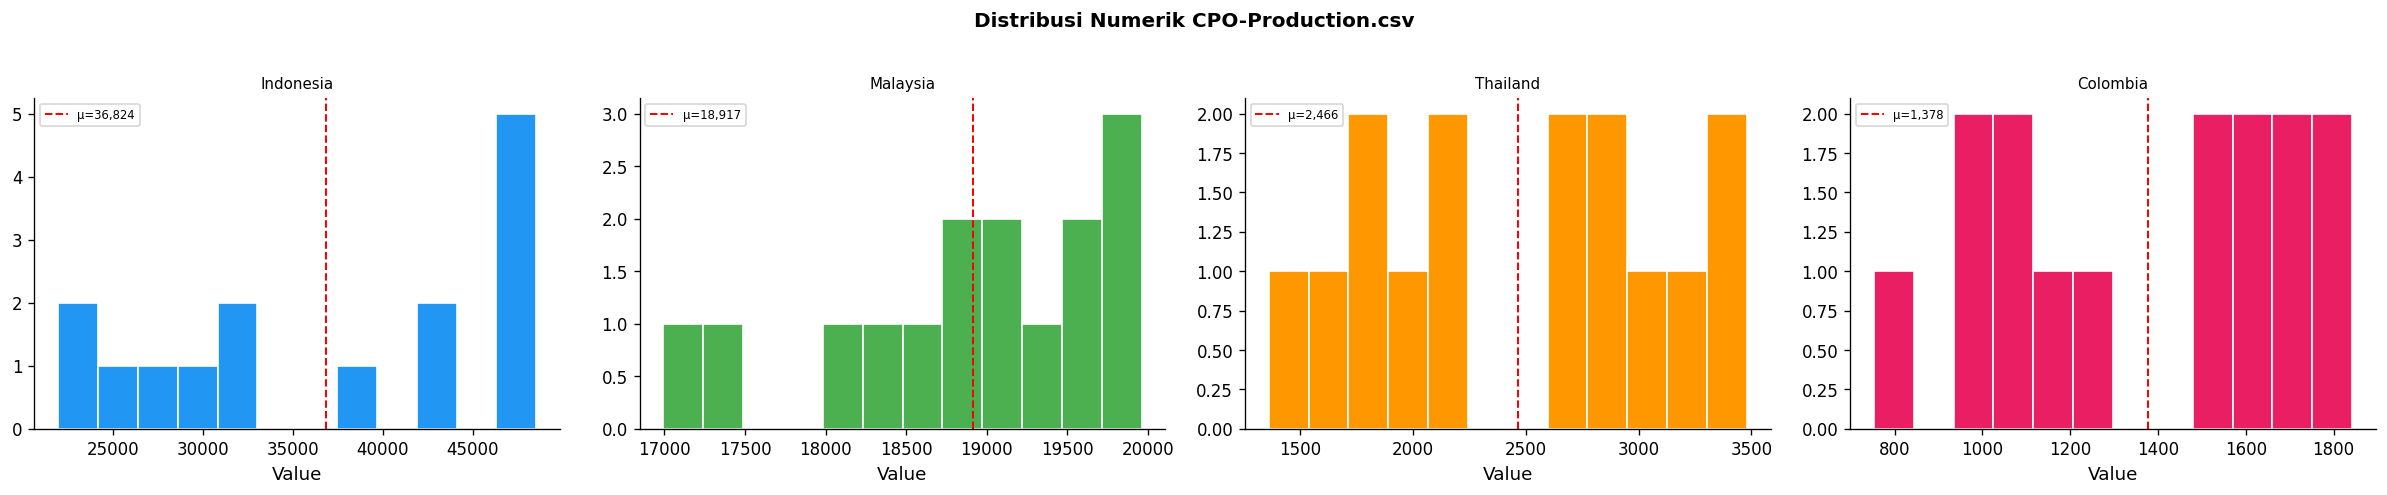

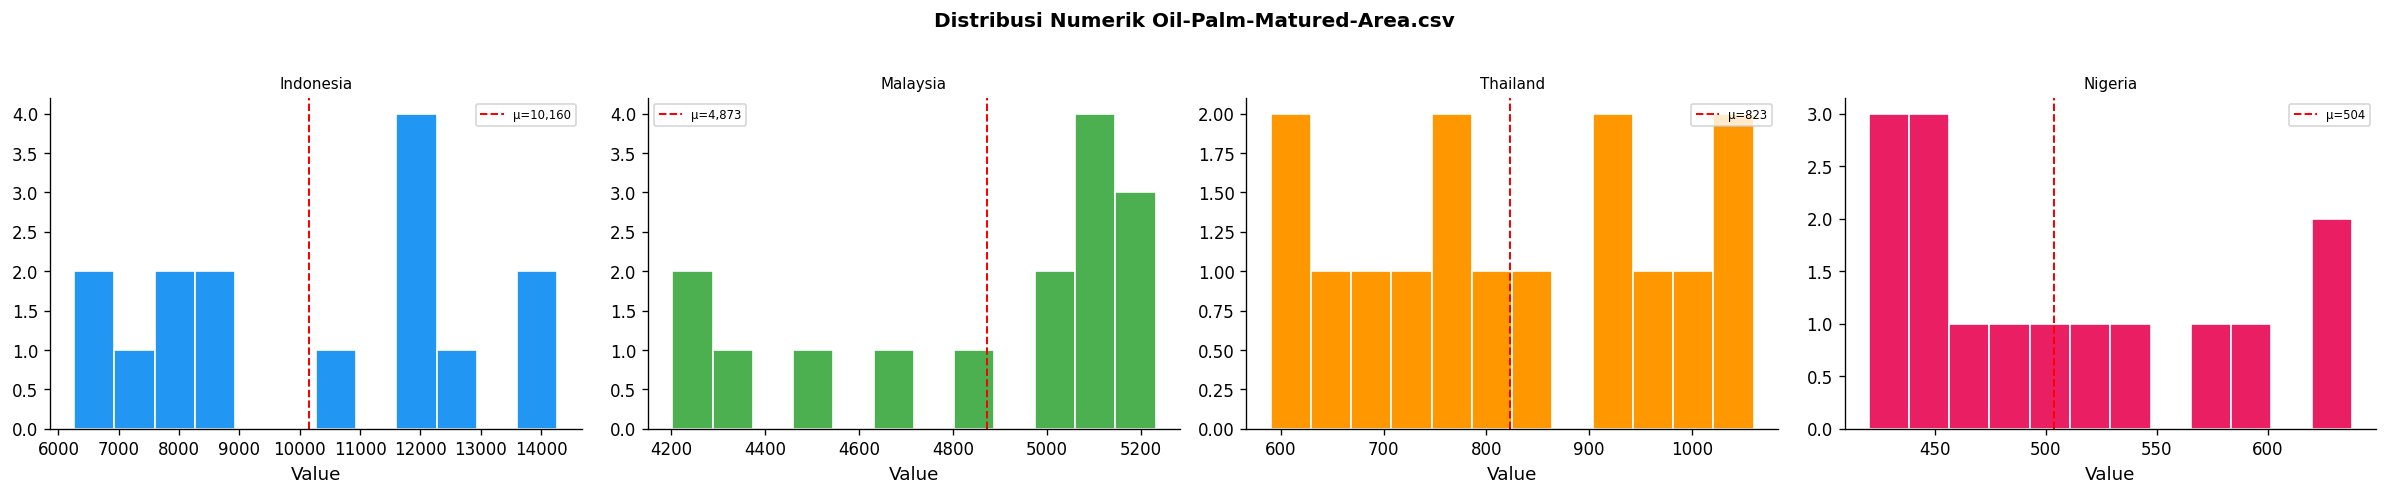

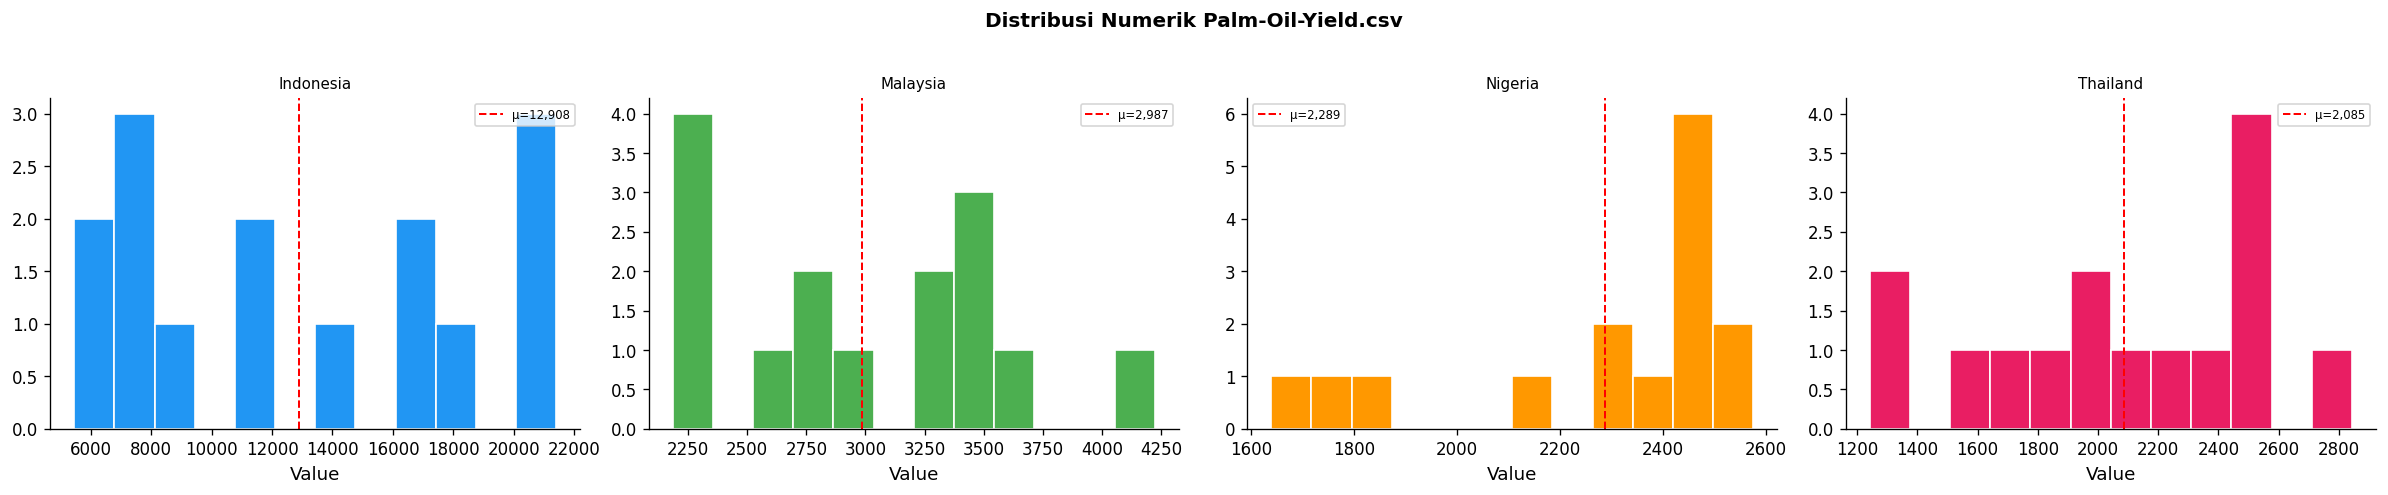

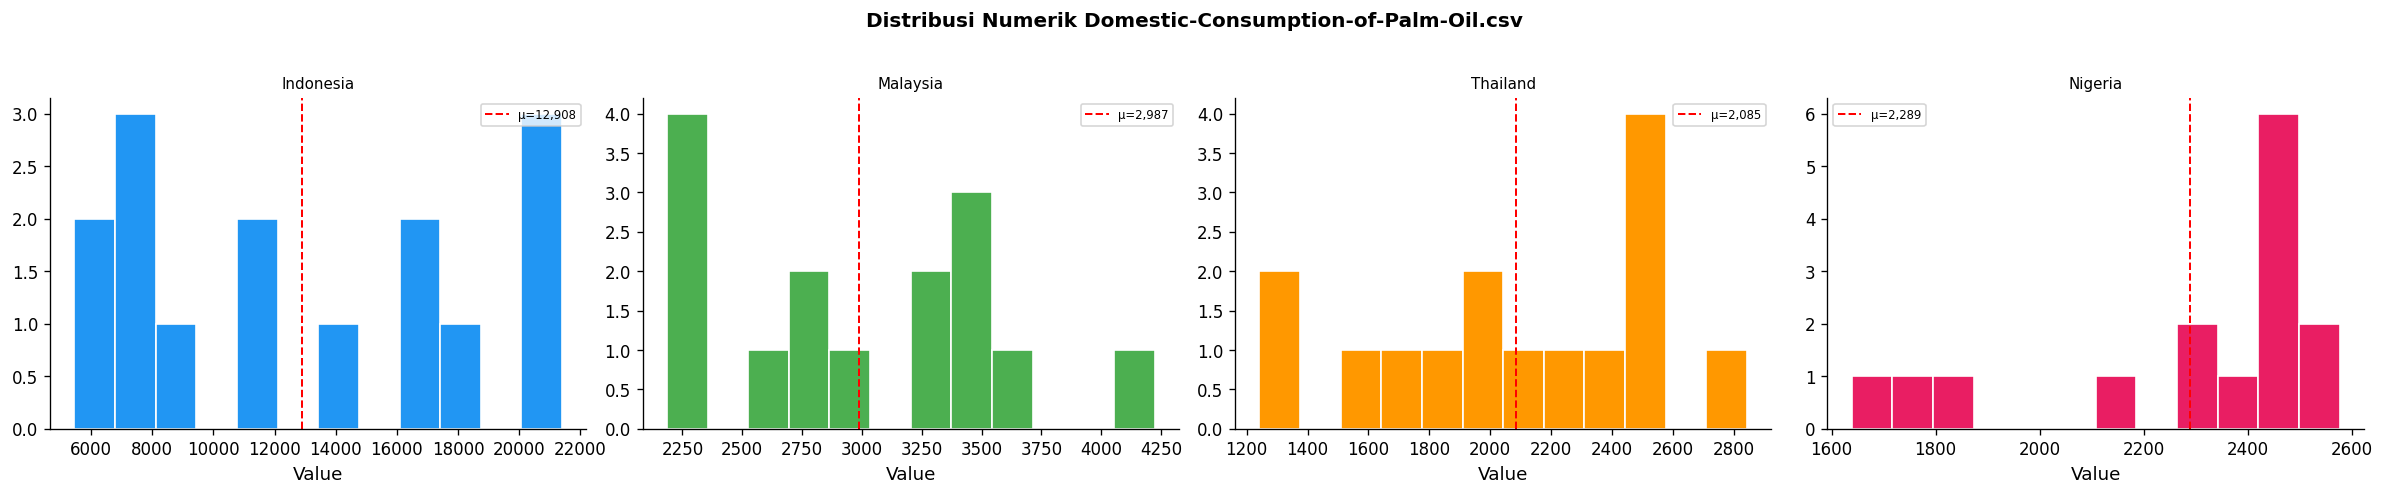

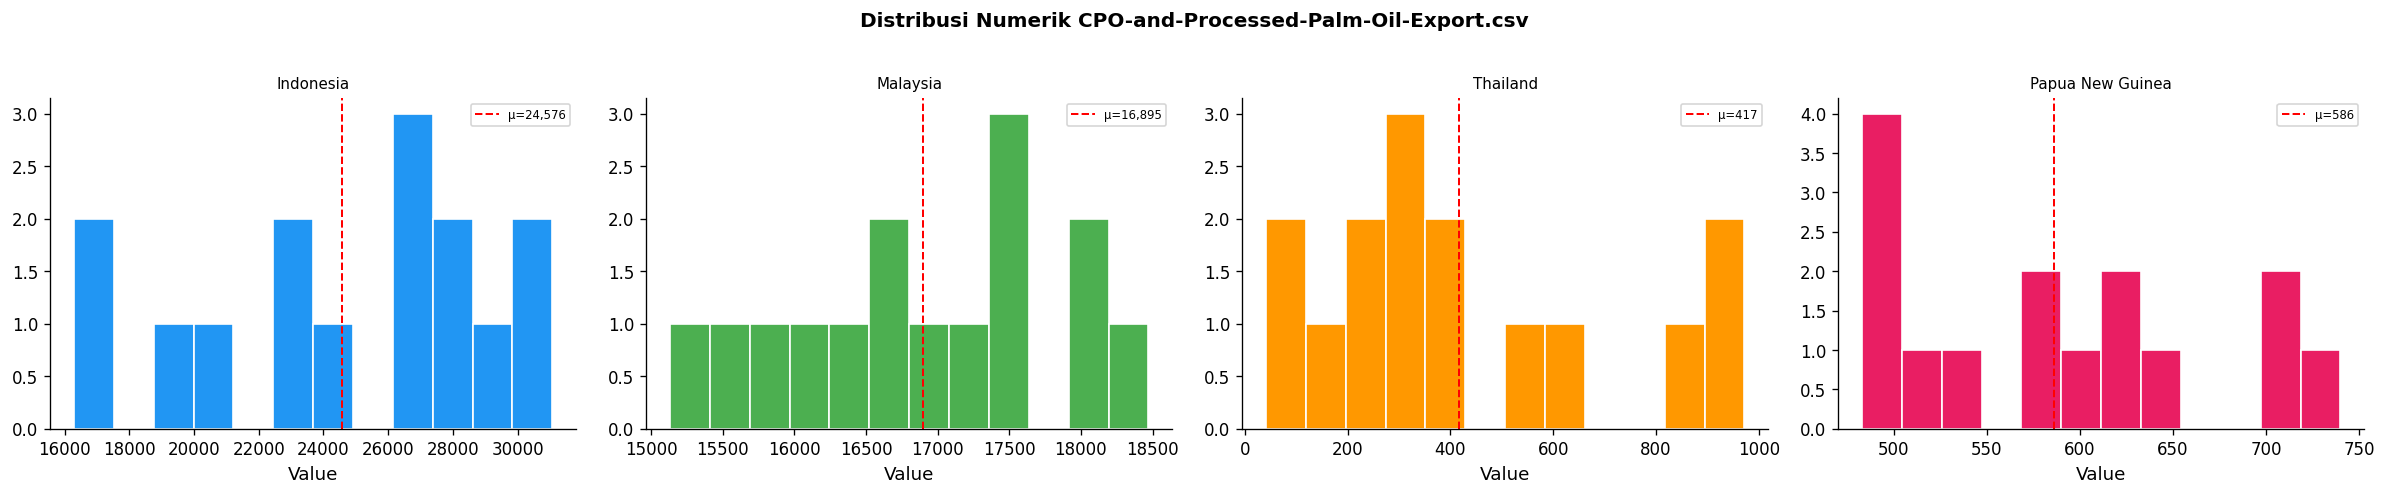

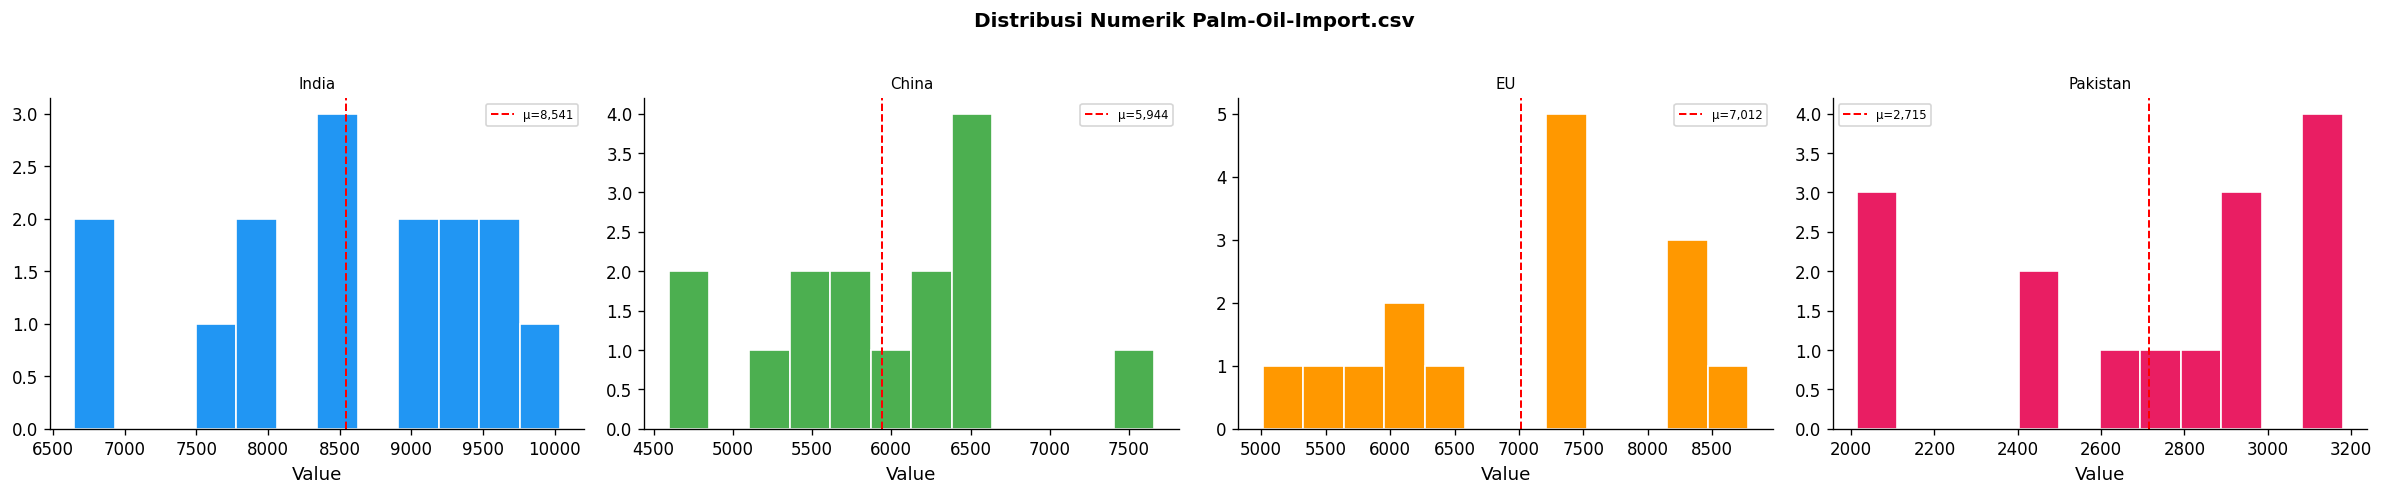

In [44]:
for key, df in raw.items():
    num_cols = [c for c in df.select_dtypes('number').columns
                if c.lower() not in ['period','year','yr']]
    if not num_cols:
        continue
    ncols = min(len(num_cols), 4)
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4), squeeze=False)
    fig.suptitle(f'Distribusi Numerik {FILE_MAP[key]}', fontweight='bold', y=1.02)
    for i, col in enumerate(num_cols[:ncols]):
        ax = axes[0][i]
        data = df[col].dropna()
        ax.hist(data, bins=12, color=PALETTE[i%len(PALETTE)], edgecolor='white', lw=0.5)
        ax.axvline(data.mean(), color='red', ls='--', lw=1.2, label=f'μ={data.mean():,.0f}')
        ax.set_title(col, fontsize=9)
        ax.set_xlabel('Value')
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

## 3.8 EDA Bivariate Trend vs Tahun

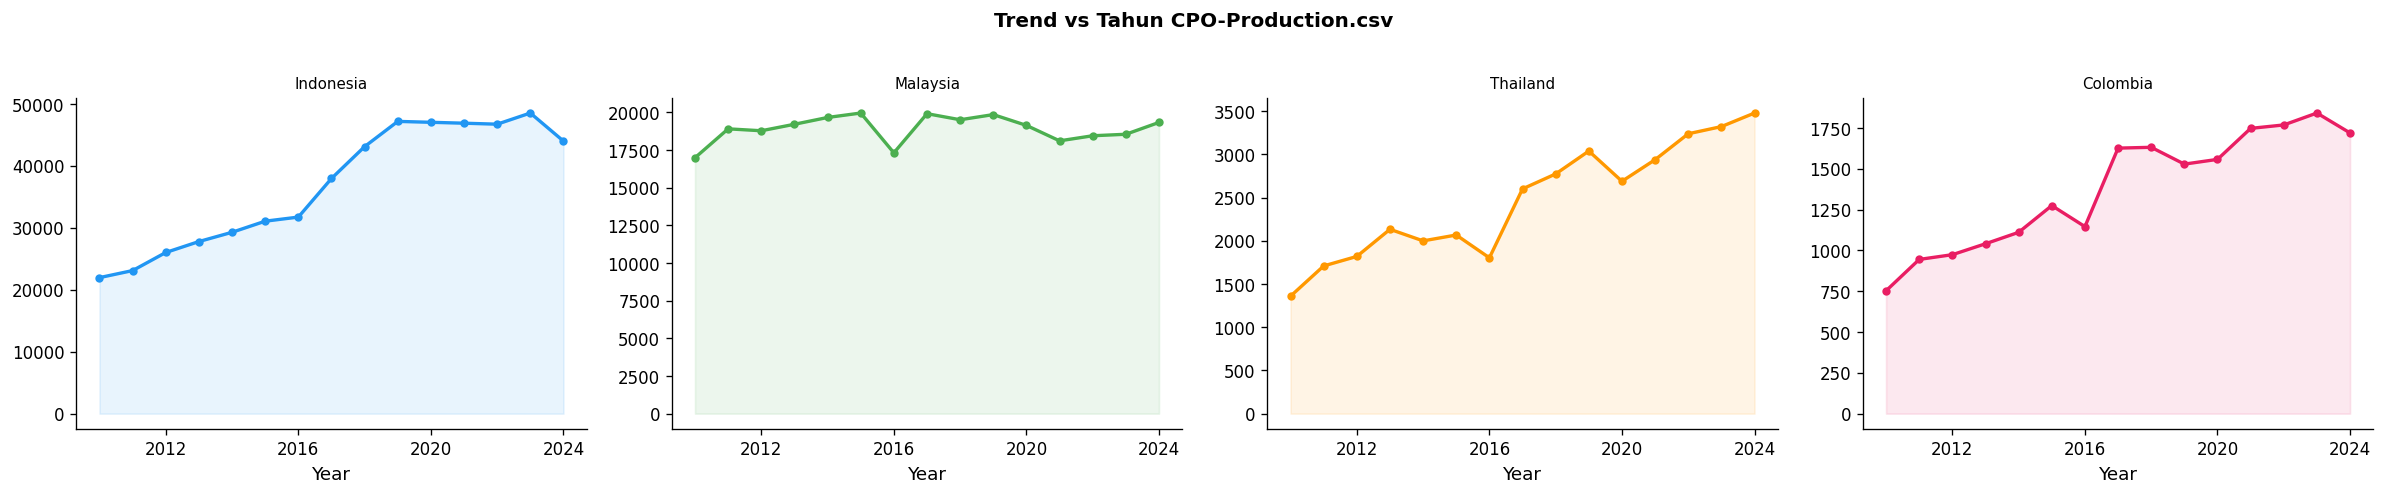

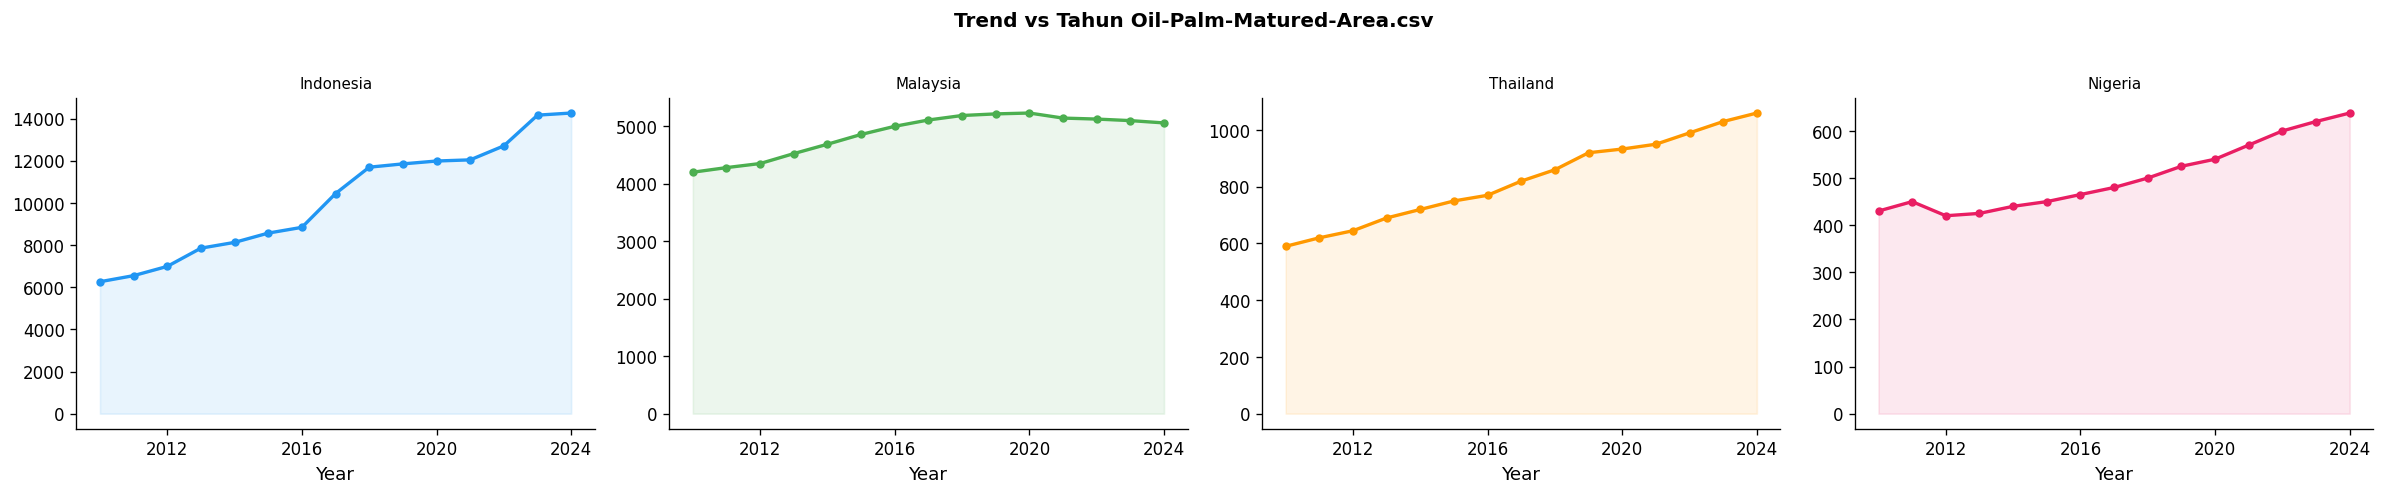

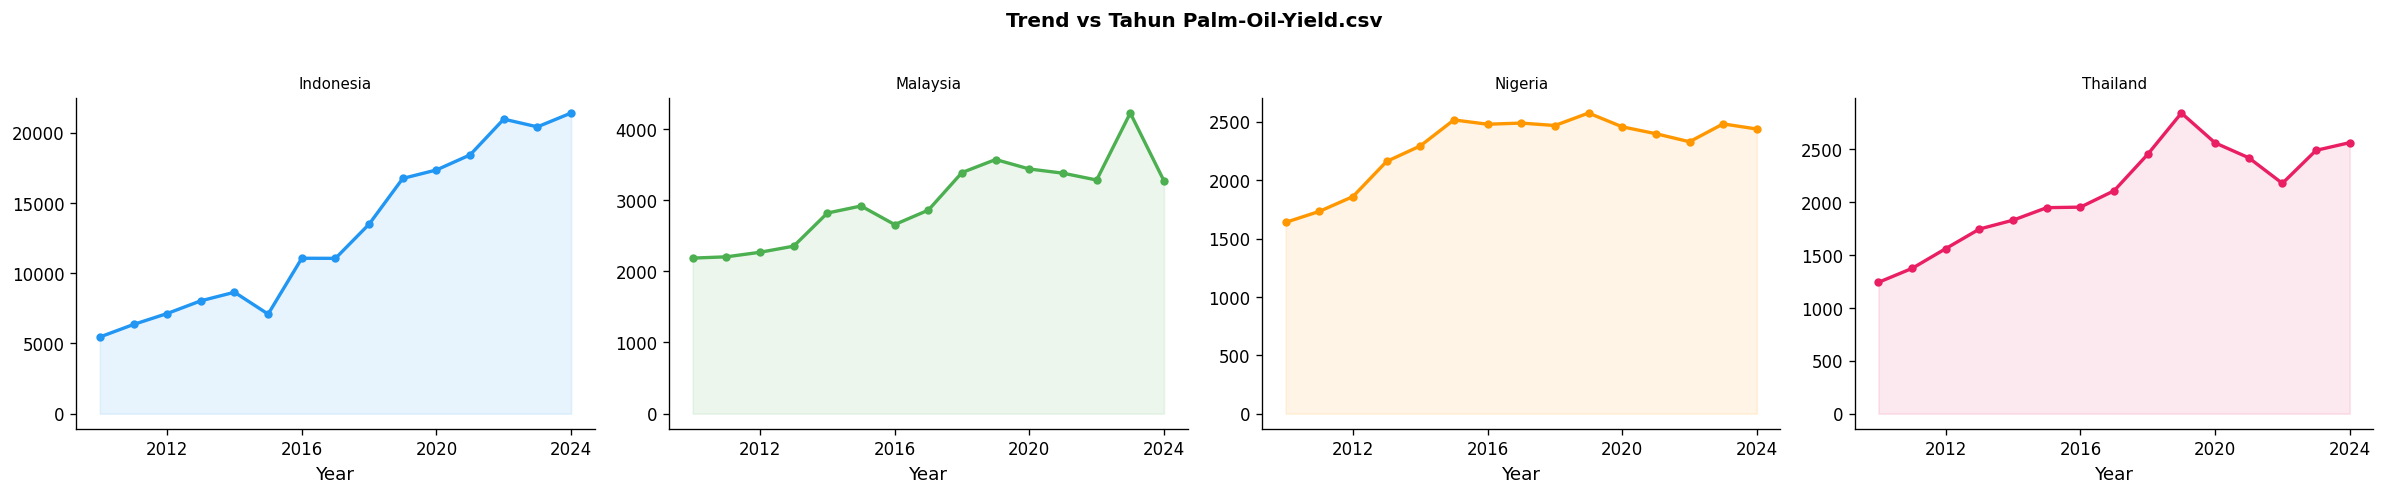

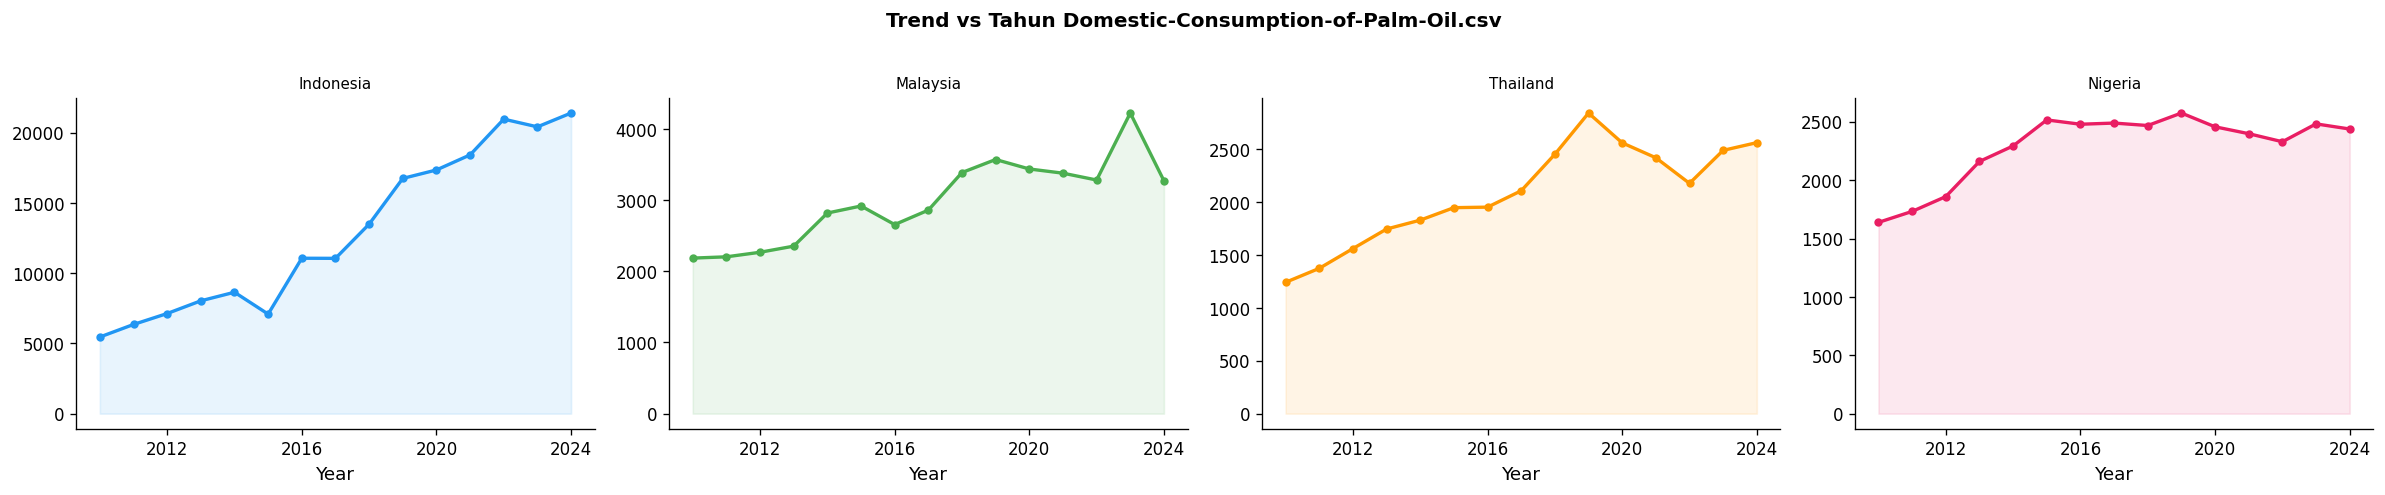

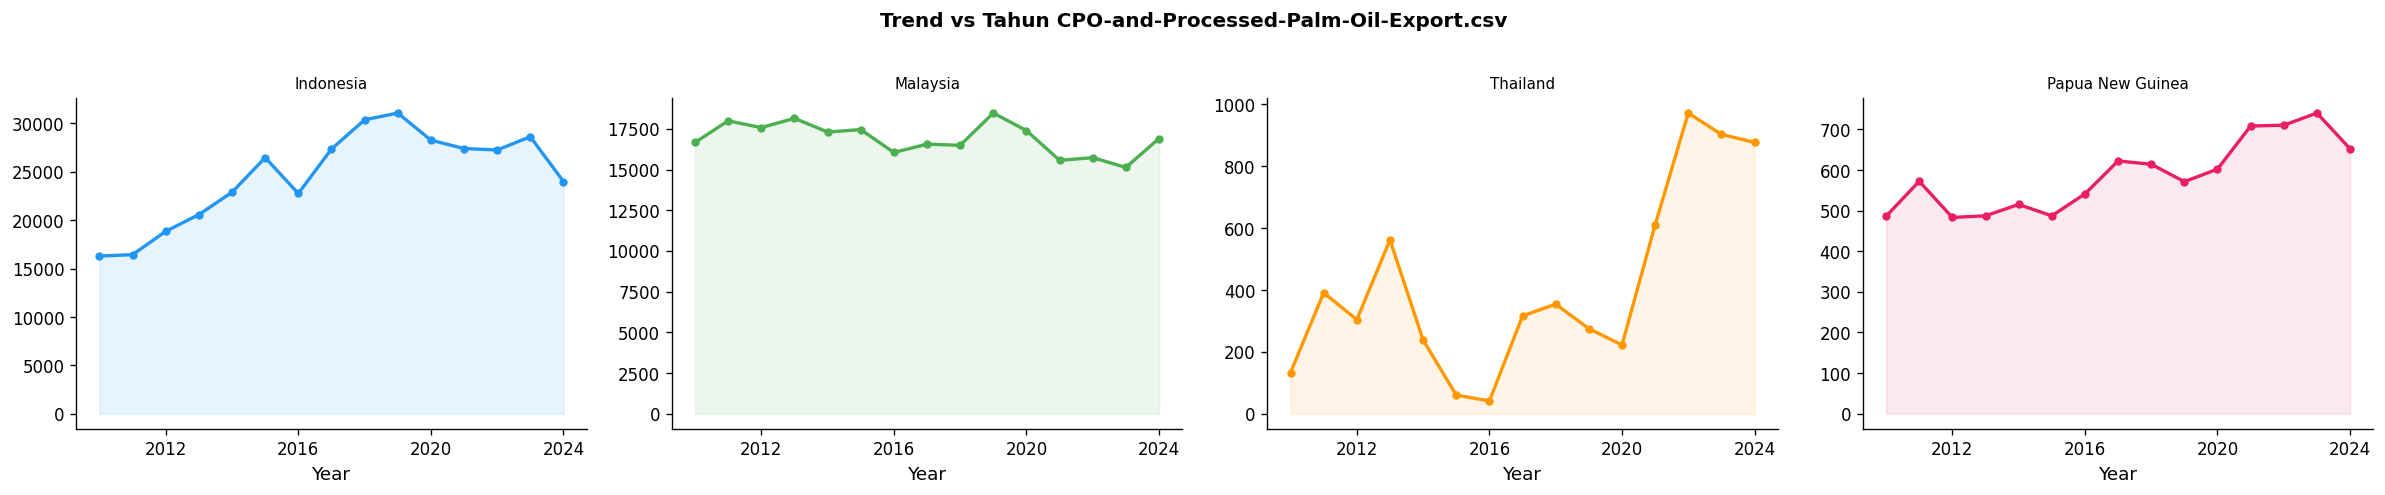

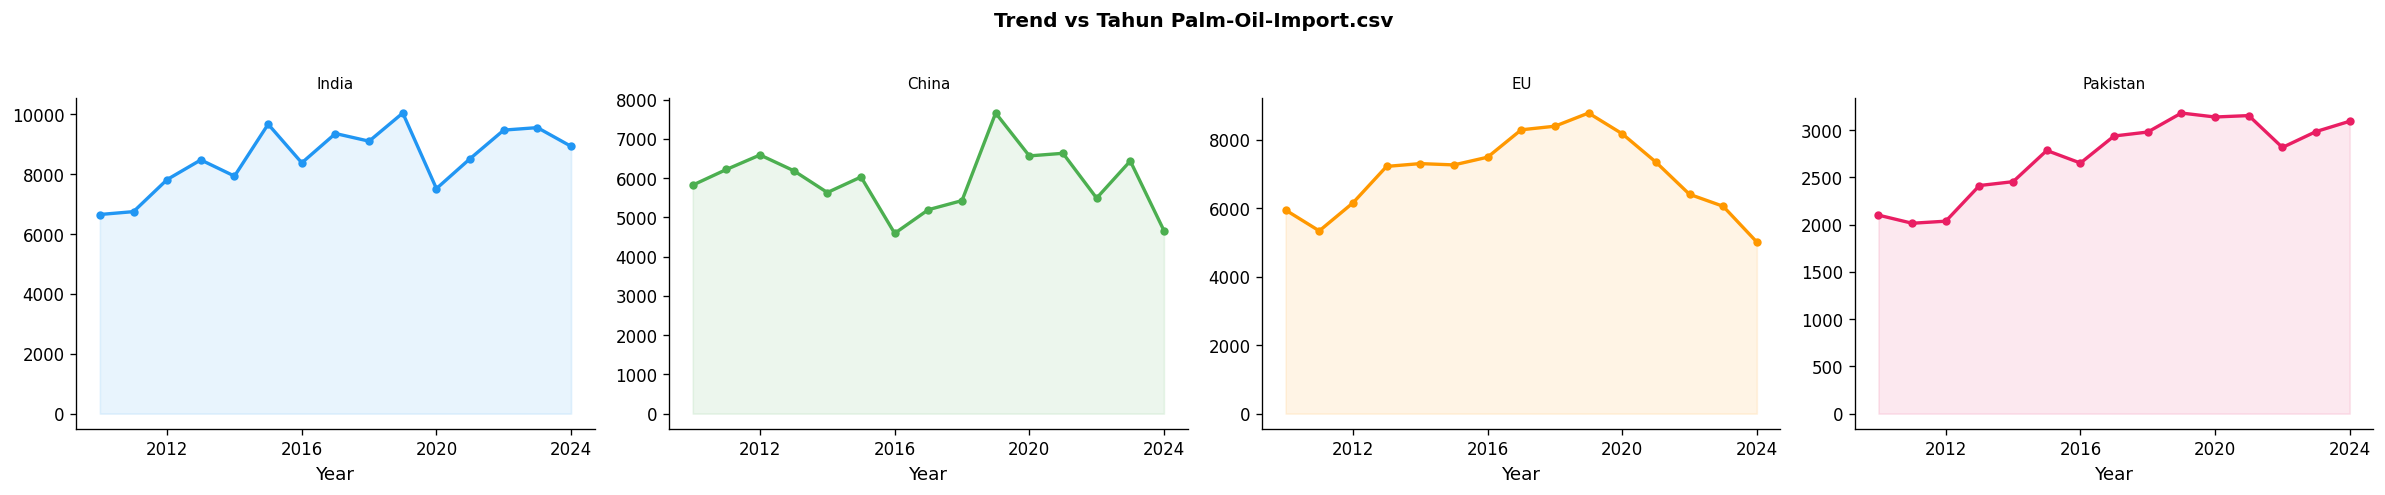

In [45]:
for key, df in raw.items():
    year_col = next((c for c in df.columns if c.lower() in ['period','year','yr']), None)
    if year_col is None:
        continue
    num_cols = [c for c in df.select_dtypes('number').columns
                if c.lower() not in ['period','year','yr']]
    if not num_cols:
        continue
    ncols = min(len(num_cols), 4)
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4), squeeze=False)
    fig.suptitle(f'Trend vs Tahun {FILE_MAP[key]}', fontweight='bold', y=1.02)
    for i, col in enumerate(num_cols[:ncols]):
        ax = axes[0][i]
        ax.plot(df[year_col], df[col], color=PALETTE[i%len(PALETTE)],
                linewidth=2, marker='o', markersize=4)
        ax.fill_between(df[year_col], df[col], alpha=0.1,
                        color=PALETTE[i%len(PALETTE)])
        ax.set_title(col, fontsize=9)
        ax.set_xlabel('Year')
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=5))
    plt.tight_layout()
    plt.show()

## 3.9 Tren Produksi CPO Malaysia (Target Variable)

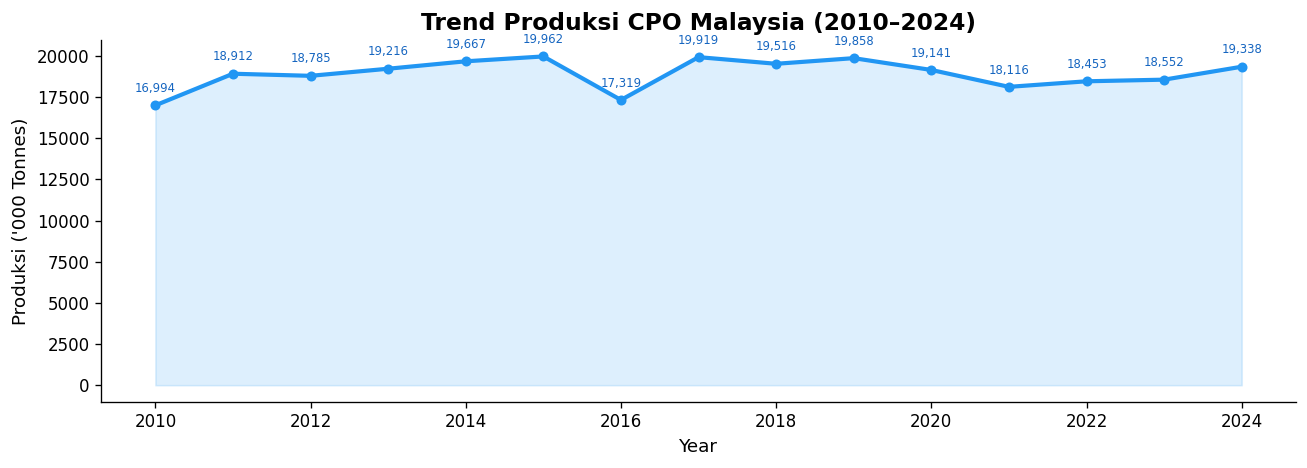


Nilai maks: 19,962 (thn 2015)
Nilai min : 16,994 (thn 2010)


In [46]:
df_p = raw['production'].copy()
year_col = next(c for c in df_p.columns if c.lower() in ['period','year','yr'])
mal_col  = next((c for c in df_p.columns if 'malaysia' in c.lower()), None)
if mal_col is None:
    num_cols = [c for c in df_p.select_dtypes('number').columns
                if c.lower() not in ['period','year','yr']]
    mal_col = num_cols[0]

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(df_p[year_col], df_p[mal_col], alpha=0.15, color='#2196F3')
ax.plot(df_p[year_col], df_p[mal_col], color='#2196F3', lw=2.5,
        marker='o', markersize=5)
for _, row in df_p.iterrows():
    ax.annotate(f"{row[mal_col]:,.0f}",
                xy=(row[year_col], row[mal_col]),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=7, color='#1565C0')
ax.set_title('Trend Produksi CPO Malaysia (2010–2024)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel("Produksi ('000 Tonnes)")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()
print(f"\nNilai maks: {df_p[mal_col].max():,.0f} (thn {df_p.loc[df_p[mal_col].idxmax(), year_col]})")
print(f"Nilai min : {df_p[mal_col].min():,.0f} (thn {df_p.loc[df_p[mal_col].idxmin(), year_col]})")

## 3.10 Tren Area Matang, Yield, Konsumsi & Ekspor

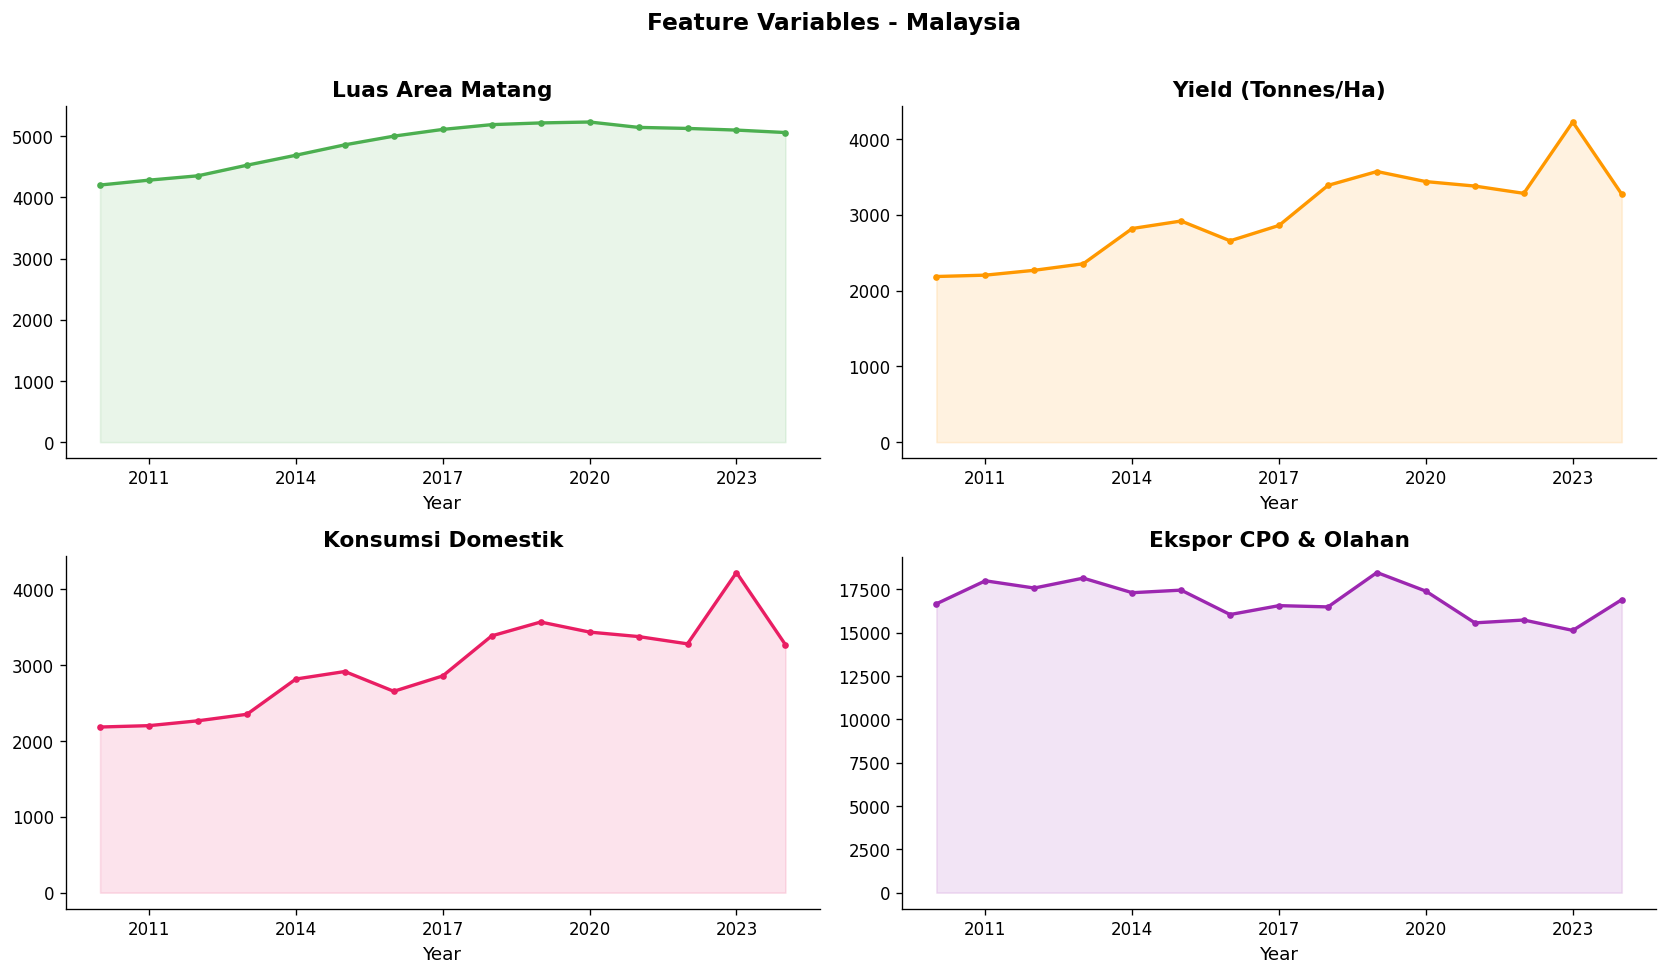

In [47]:
trend_map = {
    'matured_area' : ('Luas Area Matang',     '#4CAF50'),
    'yield_'       : ('Yield (Tonnes/Ha)',     '#FF9800'),
    'consumption'  : ('Konsumsi Domestik',     '#E91E63'),
    'export'       : ('Ekspor CPO & Olahan',   '#9C27B0'),
}
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for idx, (key, (title, color)) in enumerate(trend_map.items()):
    ax = axes[idx]
    if key not in raw:
        ax.set_title(f'{title} tidak tersedia')
        continue
    df_t = raw[key].copy()
    year_col = next((c for c in df_t.columns
                     if c.lower() in ['period','year','yr']), None)
    if year_col is None:
        continue
    num_cols = [c for c in df_t.select_dtypes('number').columns
                if c.lower() not in ['period','year','yr']]
    mal_cols = [c for c in num_cols if 'malaysia' in c.lower()]
    val_col  = mal_cols[0] if mal_cols else (num_cols[0] if num_cols else None)
    if val_col is None:
        continue
    ax.fill_between(df_t[year_col], df_t[val_col], alpha=0.12, color=color)
    ax.plot(df_t[year_col], df_t[val_col], color=color, lw=2,
            marker='o', markersize=3)
    ax.set_title(f'{title}', fontweight='bold')
    ax.set_xlabel('Year')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=6))
plt.suptitle('Feature Variables - Malaysia', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Data Preparation

## 4.1 Ekstrak Kolom Malaysia dari Setiap Dataset

In [48]:
def extract_malaysia(df, label, verbose=True):
    """
    Ambil kolom Year + kolom Malaysia dari sebuah DataFrame.
    Return DataFrame[Year, label].
    """
    df = df.copy()
    year_col = next((c for c in df.columns
                     if c.lower() in ['period','year','yr']), None)
    if year_col is None:
        raise ValueError(f"Tidak ada kolom Year/Period di '{label}'")
    num_cols = [c for c in df.select_dtypes('number').columns
                if c.lower() not in ['period','year','yr']]
    mal_cols = [c for c in num_cols if 'malaysia' in c.lower()]
    if mal_cols:
        val_col = mal_cols[0]
        note = "(kolom Malaysia ditemukan)"
    elif len(num_cols) == 1:
        val_col = num_cols[0]
        note = "(satu-satunya kolom numerik)"
    else:
        val_col = num_cols[0]
        note = f"⚠️ fallback ke kolom '{val_col}' — cek manual!"
    if verbose:
        print(f"  {'OK':3s} {label:<20} | Year='{year_col}' | Value='{val_col}' {note}")
    result = (df[[year_col, val_col]]
              .rename(columns={year_col: 'Year', val_col: label})
              .dropna(subset=['Year'])
              .assign(Year=lambda d: d['Year'].astype(int)))
    return result

print("Ekstraksi kolom Malaysia:")
df_prod  = extract_malaysia(raw['production'],   'Production')
df_area  = extract_malaysia(raw['matured_area'], 'Matured_Area')
df_yield = extract_malaysia(raw['yield_'],       'Yield')
df_cons  = extract_malaysia(raw['consumption'],  'Consumption')
df_exp   = extract_malaysia(raw['export'],       'Export')

Ekstraksi kolom Malaysia:
  OK  Production           | Year='Period' | Value='Malaysia' (kolom Malaysia ditemukan)
  OK  Matured_Area         | Year='Period' | Value='Malaysia' (kolom Malaysia ditemukan)
  OK  Yield                | Year='Period' | Value='Malaysia' (kolom Malaysia ditemukan)
  OK  Consumption          | Year='Period' | Value='Malaysia' (kolom Malaysia ditemukan)
  OK  Export               | Year='Period' | Value='Malaysia' (kolom Malaysia ditemukan)


## 4.2 Merge Semua Dataset Berdasarkan Year

In [49]:
from functools import reduce
dfs = [df_prod, df_area, df_yield, df_cons, df_exp]
df_merged = reduce(lambda l, r: pd.merge(l, r, on='Year', how='inner'), dfs)
df_merged = df_merged.sort_values('Year').reset_index(drop=True)
print(f"Merged dataset: {df_merged.shape[0]} baris × {df_merged.shape[1]} kolom")
print(f"Periode: {df_merged['Year'].min()} – {df_merged['Year'].max()}")
print()
display(df_merged)

Merged dataset: 15 baris × 6 kolom
Periode: 2010 – 2024



,Year,Production,Matured_Area,Yield,Consumption,Export
0,2010,16994,4202,2185,2185,16664
1,2011,18912,4282,2203,2203,17993
2,2012,18785,4353,2267,2267,17575
3,2013,19216,4526,2353,2353,18147
4,2014,19667,4689,2818,2818,17306
5,2015,19962,4859,2917,2917,17454
6,2016,17319,5001,2656,2656,16046
7,2017,19919,5111,2859,2859,16560
8,2018,19516,5189,3387,3387,16487
9,2019,19858,5217,3570,3570,18471


## 4.3 Handle Missing Value

In [50]:
print("Missing value setelah merge:")
mv = df_merged.isnull().sum()
display(mv.to_frame('Missing'))
if mv.sum() > 0:
    df_merged = df_merged.interpolate(method='linear', limit_direction='both')
    print("✅ Missing value diisi dengan interpolasi linear.")
else:
    print("❎ Tidak ada missing value.")

Missing value setelah merge:


,Missing
Year,0
Production,0
Matured_Area,0
Yield,0
Consumption,0
Export,0


❎ Tidak ada missing value.


## 4.4 Handle Outlier (IQR Winsorizing)

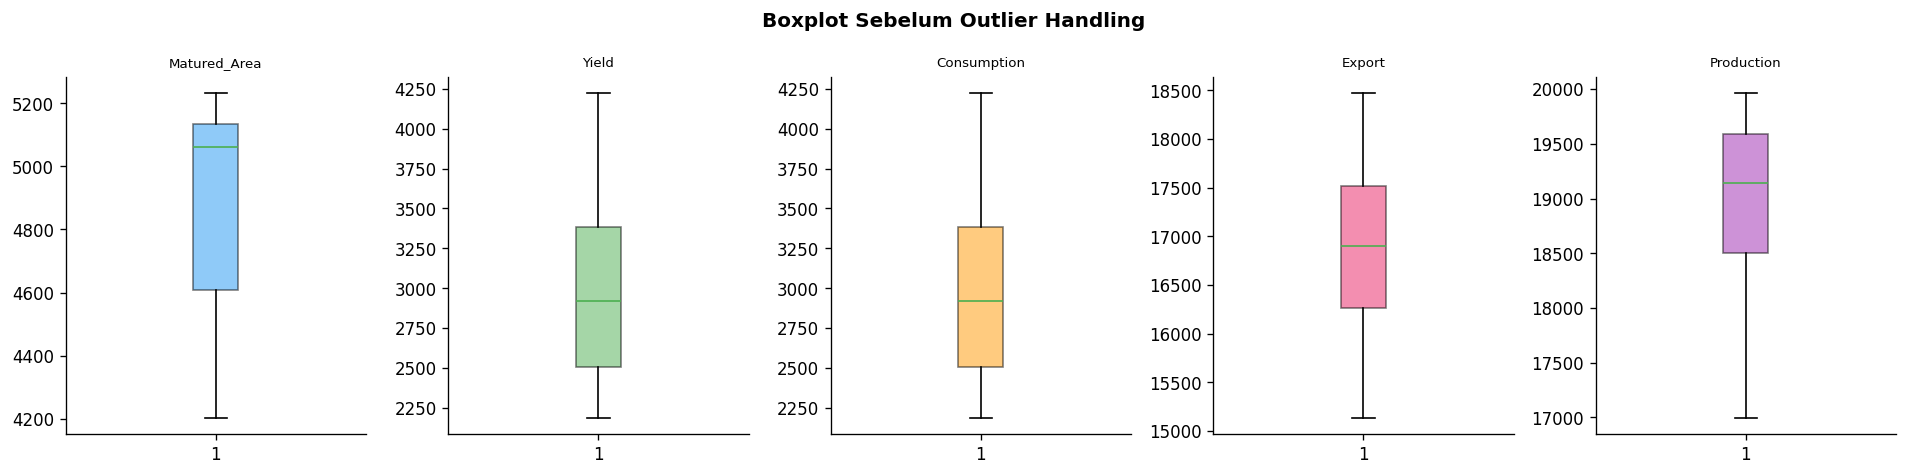

,Kolom,Outlier,Lower,Upper
0,Matured_Area,0,3815.5,5927.5
1,Yield,0,1187.5,4699.5
2,Consumption,0,1187.5,4699.5
3,Export,0,14394.5,19386.5
4,Production,0,16869.0,21225.0



Outlier di-cap (winsorized). ✅ Data bersih: (15, 6)


In [51]:
FEATURE_COLS = ['Matured_Area', 'Yield', 'Consumption', 'Export']
TARGET_COL   = 'Production'
ALL_COLS     = FEATURE_COLS + [TARGET_COL]

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for i, col in enumerate(ALL_COLS):
    axes[i].boxplot(df_merged[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=PALETTE[i%len(PALETTE)], alpha=0.5))
    axes[i].set_title(col, fontsize=8)
plt.suptitle('Boxplot Sebelum Outlier Handling', fontweight='bold')
plt.tight_layout(); plt.show()

df_clean = df_merged.copy()
report   = []

for col in ALL_COLS:
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out  = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    df_clean[col] = df_clean[col].clip(lo, hi)
    report.append({'Kolom': col, 'Outlier': n_out,
                   'Lower': round(lo,1), 'Upper': round(hi,1)})

display(pd.DataFrame(report))
print(f"\nOutlier di-cap (winsorized). ✅ Data bersih: {df_clean.shape}")

## 4.5 Correlation Heatmap

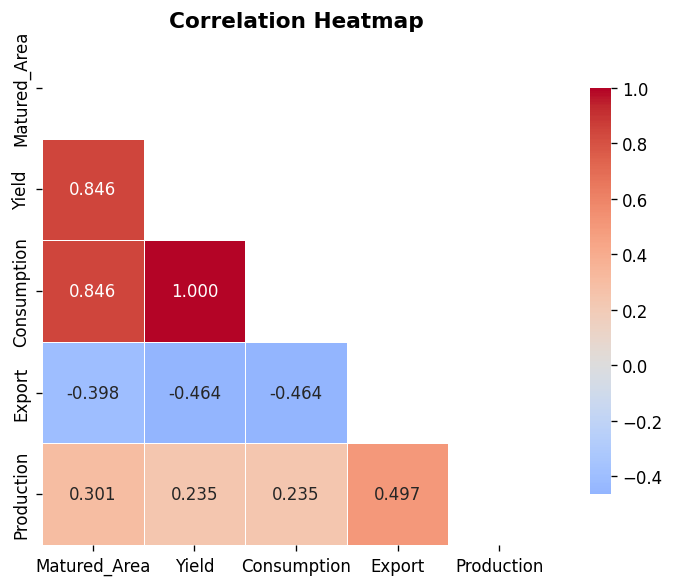


📊 Korelasi terhadap Production:


,Korelasi
Export,0.4969
Matured_Area,0.3009
Yield,0.2349
Consumption,0.2349


In [52]:
corr = df_clean[ALL_COLS].corr()
fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()
print("\n📊 Korelasi terhadap Production:")
display(corr['Production'].drop('Production')
        .sort_values(ascending=False).to_frame('Korelasi').round(4))

## 4.6 Feature Selection & Train-Test Split

In [53]:
FEATURES = ['Matured_Area', 'Yield', 'Consumption', 'Export']
TARGET   = 'Production'
X      = df_clean[FEATURES].values
y      = df_clean[TARGET].values
years  = df_clean['Year'].values
X_train, X_test, y_train, y_test, yr_train, yr_test = train_test_split(
    X, y, years, test_size=0.2, random_state=42
)
print(f"Train   : {X_train.shape[0]} sampel | Test: {X_test.shape[0]} sampel")
print(f"Features: {FEATURES}")
print(f"Target  : {TARGET}")

Train   : 12 sampel | Test: 3 sampel
Features: ['Matured_Area', 'Yield', 'Consumption', 'Export']
Target  : Production


## 4.7 Scaling (StandardScaler Linear Regression)

In [54]:
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ StandardScaler fitted.")
scale_df = pd.DataFrame({'Feature': FEATURES,
                          'Mean': scaler.mean_.round(2),
                          'Std' : scaler.scale_.round(2)})
display(scale_df)

✅ StandardScaler fitted.


,Feature,Mean,Std
0,Matured_Area,4877.42,319.72
1,Yield,2972.75,559.01
2,Consumption,2972.75,559.01
3,Export,16893.92,886.72


# Modeling

In [55]:
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  Model : {name}")
    print(f"  MAE   : {mae:,.2f}")
    print(f"  RMSE  : {rmse:,.2f}")
    print(f"  R²    : {r2:.4f}")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}
def plot_eval(name, y_true, y_pred, color='#2196F3'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ax = axes[0]
    ax.scatter(y_true, y_pred, color=color, alpha=0.75, s=70, edgecolors='white')
    lims = [min(y_true.min(), y_pred.min())*0.95,
            max(y_true.max(), y_pred.max())*1.05]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect Fit')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(f'{name} — Actual vs Predicted', fontweight='bold')
    ax.legend()
    residuals = y_true - y_pred
    ax = axes[1]
    ax.bar(range(len(residuals)), residuals, color=color, alpha=0.7, edgecolor='white')
    ax.axhline(0, color='red', ls='--', lw=1)
    ax.set_xlabel('Sample'); ax.set_ylabel('Residual')
    ax.set_title(f'{name} — Residual Plot', fontweight='bold')
    plt.tight_layout(); plt.show()
print("✅ Helper siap.")

✅ Helper siap.


## 5.1 Linear Regression

In [56]:
with mlflow.start_run(run_name="Linear Regression"):
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train)
    y_pred_lr = lr.predict(X_test_scaled)

    res_lr = evaluate_model('Linear Regression', y_test, y_pred_lr)

    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_metric("MAE", res_lr['MAE'])
    mlflow.log_metric("RMSE", res_lr['RMSE'])
    mlflow.log_metric("R2", res_lr['R2'])
    mlflow.sklearn.log_model(lr, "model")

    cv_lr = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='r2')
    print(f"Cross-Val R² (5-fold): mean={cv_lr.mean():.4f}")
    coef_df = pd.DataFrame({'Feature': FEATURES, 'Coef': lr.coef_}).sort_values('Coef', key=abs, ascending=False)
    display(coef_df)

  Model : Linear Regression
  MAE   : 781.81
  RMSE  : 851.66
  R²    : 0.4776


2026/06/13 15:07:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 15:07:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Cross-Val R² (5-fold): mean=-18.4222


,Feature,Coef
3,Export,714.997996
0,Matured_Area,191.305473
2,Consumption,187.883892
1,Yield,187.883892


🏃 View run Linear Regression at: https://dagshub.com/oshlite/palm-oil-intelligence-platform.mlflow/#/experiments/1/runs/4c91fbb22b4c479988cf958c680a3436
🧪 View experiment at: https://dagshub.com/oshlite/palm-oil-intelligence-platform.mlflow/#/experiments/1


  Model : Linear Regression
  MAE   : 781.81
  RMSE  : 851.66
  R²    : 0.4776


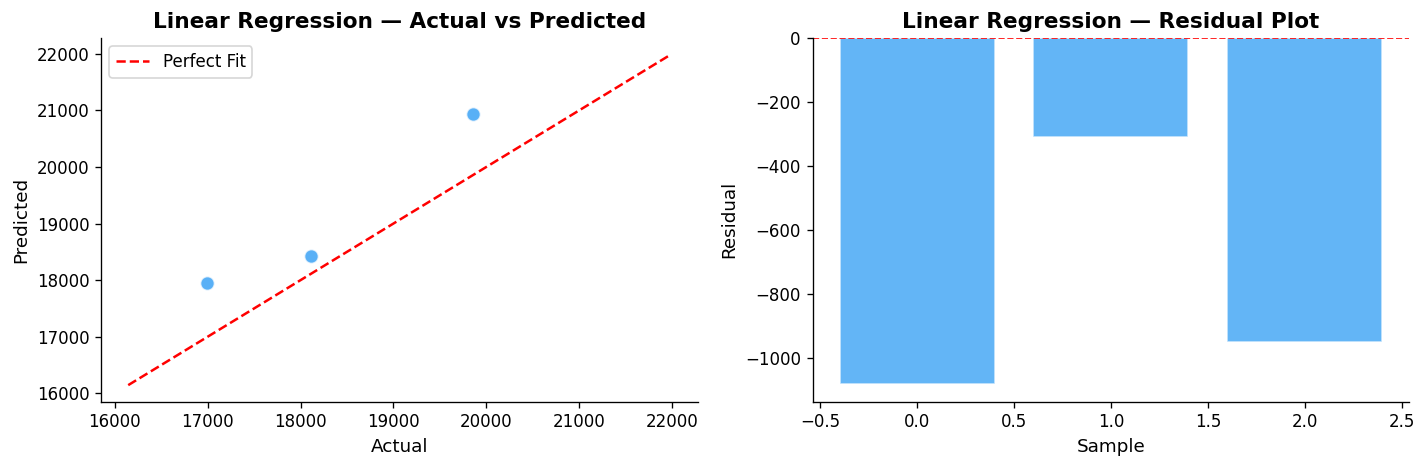

In [57]:
res_lr = evaluate_model('Linear Regression', y_test, y_pred_lr)
plot_eval('Linear Regression', y_test, y_pred_lr, '#2196F3')

## 5.2 Random Forest Regressor

In [58]:
with mlflow.start_run(run_name="Random Forest"):
    n_est = 200
    rf = RandomForestRegressor(n_estimators=n_est, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)

    res_rf = evaluate_model('Random Forest', y_test, y_pred_rf)

    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", n_est)
    mlflow.log_metric("MAE", res_rf['MAE'])
    mlflow.log_metric("RMSE", res_rf['RMSE'])
    mlflow.log_metric("R2", res_rf['R2'])
    mlflow.sklearn.log_model(rf, "model")

    cv_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
    print(f"Cross-Val R² (5-fold): mean={cv_rf.mean():.4f}")

  Model : Random Forest
  MAE   : 1,037.21
  RMSE  : 1,347.18
  R²    : -0.3071


2026/06/13 15:07:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 15:07:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Cross-Val R² (5-fold): mean=-2.0414
🏃 View run Random Forest at: https://dagshub.com/oshlite/palm-oil-intelligence-platform.mlflow/#/experiments/1/runs/44d3457af3394b8db3624ea678d896cd
🧪 View experiment at: https://dagshub.com/oshlite/palm-oil-intelligence-platform.mlflow/#/experiments/1


  Model : Random Forest
  MAE   : 1,037.21
  RMSE  : 1,347.18
  R²    : -0.3071


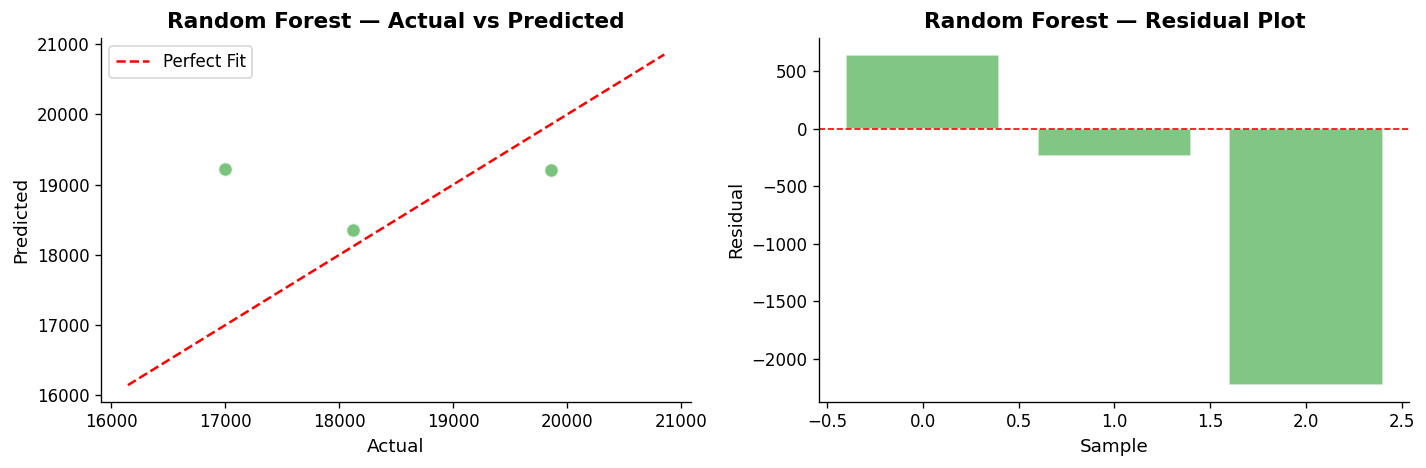

In [59]:
res_rf = evaluate_model('Random Forest', y_test, y_pred_rf)
plot_eval('Random Forest', y_test, y_pred_rf, '#4CAF50')

## 5.3 XGBoost Regressor

In [60]:
with mlflow.start_run(run_name="XGBoost"):
    params = {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    }
    xgb = XGBRegressor(**params, random_state=42, verbosity=0, n_jobs=-1)
    xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    y_pred_xgb = xgb.predict(X_test)

    res_xgb = evaluate_model('XGBoost', y_test, y_pred_xgb)

    mlflow.log_params(params)
    mlflow.log_metric("MAE", res_xgb['MAE'])
    mlflow.log_metric("RMSE", res_xgb['RMSE'])
    mlflow.log_metric("R2", res_xgb['R2'])
    mlflow.xgboost.log_model(xgb, "model")

    cv_xgb = cross_val_score(xgb, X_train, y_train, cv=5, scoring='r2')
    print(f"Cross-Val R² (5-fold): mean={cv_xgb.mean():.4f}")

  Model : XGBoost
  MAE   : 937.00
  RMSE  : 1,174.69
  R²    : 0.0061


2026/06/13 15:08:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Cross-Val R² (5-fold): mean=-3.0388
🏃 View run XGBoost at: https://dagshub.com/oshlite/palm-oil-intelligence-platform.mlflow/#/experiments/1/runs/1e952a28c67f458eb3a3b6b975fa7d2e
🧪 View experiment at: https://dagshub.com/oshlite/palm-oil-intelligence-platform.mlflow/#/experiments/1


  Model : XGBoost
  MAE   : 937.00
  RMSE  : 1,174.69
  R²    : 0.0061


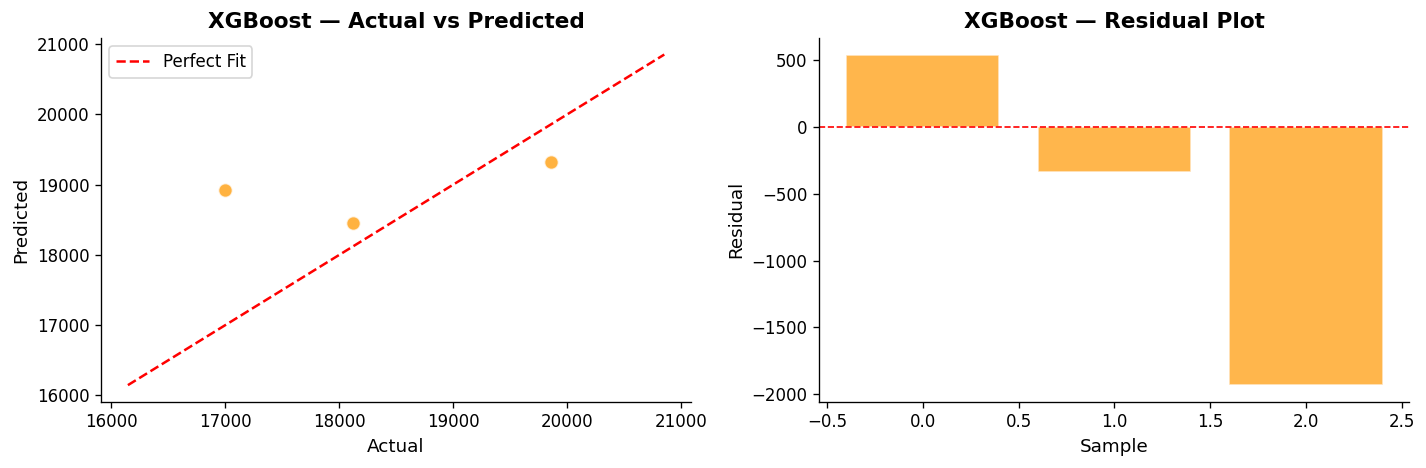

In [61]:
res_xgb = evaluate_model('XGBoost', y_test, y_pred_xgb)
plot_eval('XGBoost', y_test, y_pred_xgb, '#FF9800')

# Evaluation & Model Comparison

## 6.1 Model Comparison

In [62]:
results_df = (pd.DataFrame([res_lr, res_rf, res_xgb])
               .set_index('Model')
               .round({'MAE':2,'RMSE':2,'R2':4}))
display(results_df.style
        .format({'MAE':'{:,.2f}','RMSE':'{:,.2f}','R2':'{:.4f}'})
        .background_gradient(cmap='RdYlGn', subset=['R2'])
        .background_gradient(cmap='RdYlGn_r', subset=['MAE','RMSE'])
        .set_caption("🟢 Hijau = lebih baik"))

,MAE,RMSE,R2
Model,,,
Linear Regression,781.81,851.66,0.4776
Random Forest,"1,037.21","1,347.18",-0.3071
XGBoost,937.00,"1,174.69",0.0061


## 6.2 Perbandingan Metrik

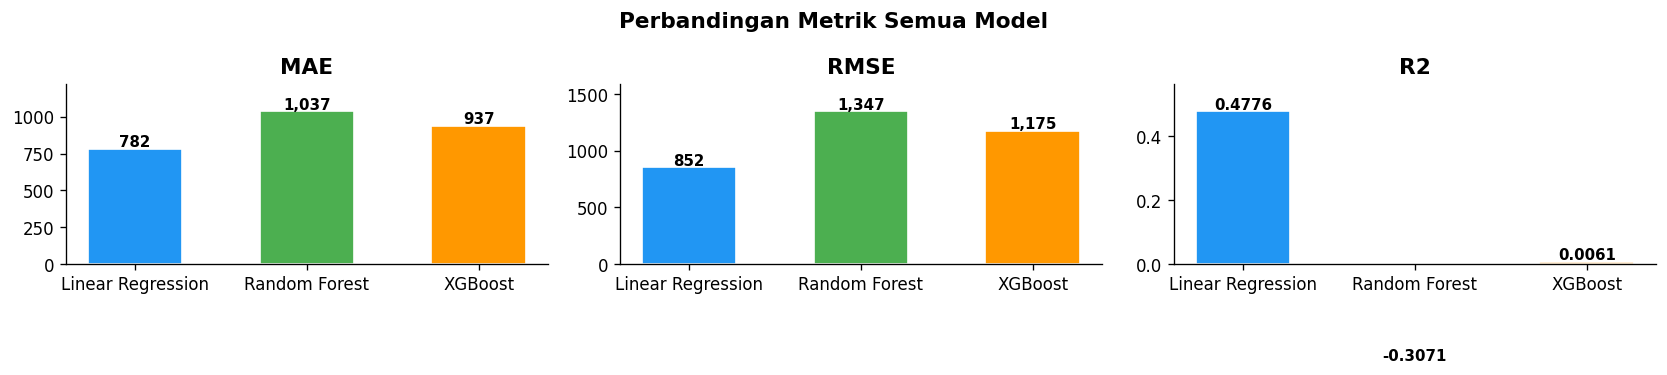


🏆 Model Terbaik : Linear Regression
    R²   : 0.4776
    MAE  : 781.81
    RMSE : 851.66


In [63]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, metric in enumerate(['MAE','RMSE','R2']):
    ax = axes[i]
    vals = results_df[metric]
    bars = ax.bar(vals.index, vals.values, color=PALETTE[:3],
                  edgecolor='white', width=0.55)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + max(vals)*0.015,
                f'{val:.4f}' if metric=='R2' else f'{val:,.0f}',
                ha='center', fontsize=9, fontweight='bold')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, max(vals)*1.18)
plt.suptitle('Perbandingan Metrik Semua Model', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
best_name = results_df['R2'].idxmax()
print(f"\n🏆 Model Terbaik : {best_name}")
print(f"    R²   : {results_df.loc[best_name,'R2']:.4f}")
print(f"    MAE  : {results_df.loc[best_name,'MAE']:,.2f}")
print(f"    RMSE : {results_df.loc[best_name,'RMSE']:,.2f}")

## 6.3 Overlay plot Actual vs model prediksi

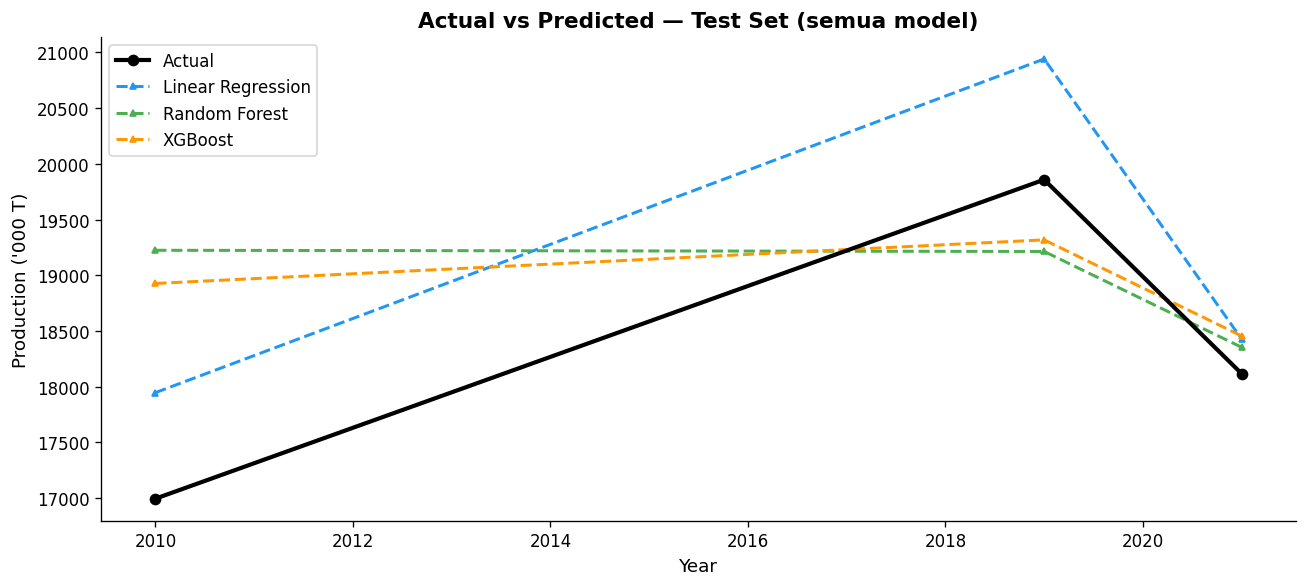

In [64]:
pred_map = {
    'Linear Regression': y_pred_lr,
    'Random Forest'    : y_pred_rf,
    'XGBoost'          : y_pred_xgb,
}
colors_map = {'Linear Regression':'#2196F3','Random Forest':'#4CAF50','XGBoost':'#FF9800'}
fig, ax = plt.subplots(figsize=(11, 5))
sidx = np.argsort(yr_test)
ax.plot(yr_test[sidx], y_test[sidx], 'k-o', lw=2.5, ms=6, label='Actual', zorder=5)
for mname, preds in pred_map.items():
    ax.plot(yr_test[sidx], preds[sidx], '--', color=colors_map[mname],
            lw=1.8, ms=4, marker='^', label=mname)
ax.set_title('Actual vs Predicted — Test Set (semua model)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel("Production ('000 T)")
ax.legend(); ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout(); plt.show()

# Feature Analysis

## 7.1 Feature Importance Random Forest

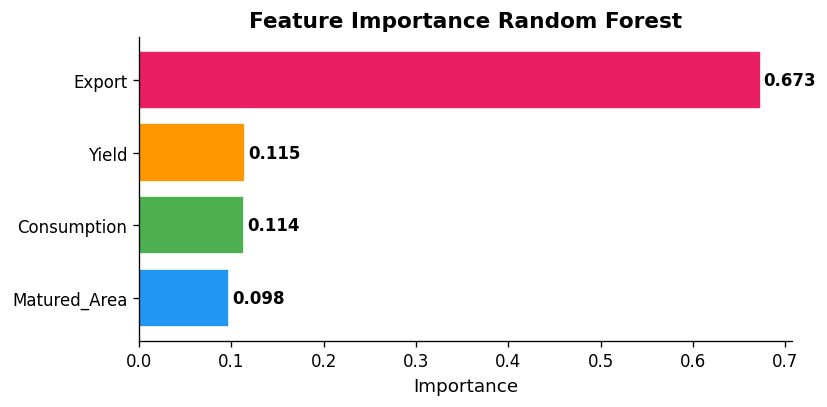

In [65]:
fi_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(fi_rf.index, fi_rf.values, color=PALETTE[:4], edgecolor='white')
for bar, val in zip(bars, fi_rf.values):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontweight='bold')
ax.set_title('Feature Importance Random Forest', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

## 7.2 Feature Importance XGBoost

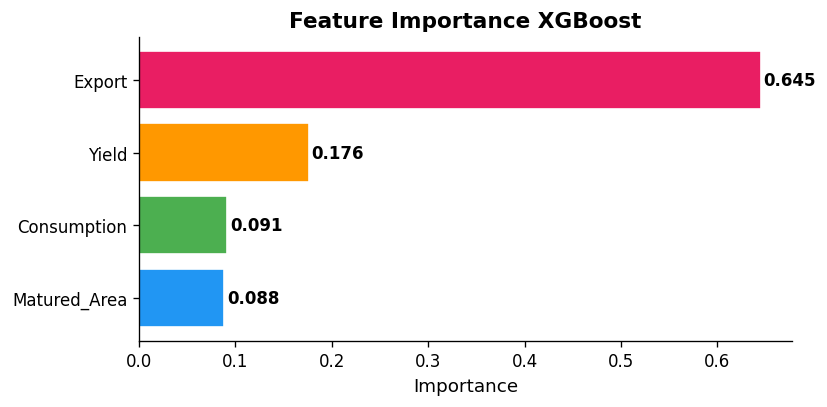

In [66]:
fi_xgb = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(fi_xgb.index, fi_xgb.values, color=PALETTE[:4], edgecolor='white')
for bar, val in zip(bars, fi_xgb.values):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontweight='bold')
ax.set_title('Feature Importance XGBoost', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

## 7.3 Permutation Importance (Model-Agnostic)

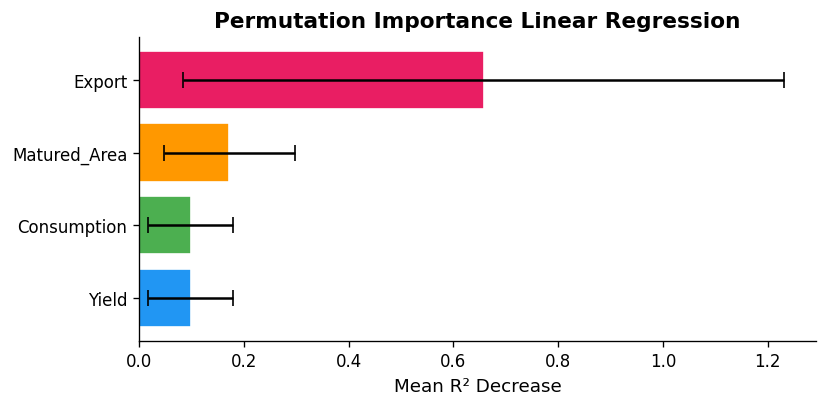


Ranking Faktor Paling Berpengaruh:
  Export               : 0.6575 ± 0.5730
  Matured_Area         : 0.1726 ± 0.1246
  Consumption          : 0.0984 ± 0.0812
  Yield                : 0.0984 ± 0.0812


In [67]:
model_lookup = {
    'Linear Regression': (lr,  X_test_scaled),
    'Random Forest'    : (rf,  X_test),
    'XGBoost'          : (xgb, X_test),
}
best_model_obj, best_X = model_lookup[best_name]
perm = permutation_importance(best_model_obj, best_X, y_test,
                              n_repeats=20, random_state=42, scoring='r2')
perm_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': perm.importances_mean,
    'Std'       : perm.importances_std
}).sort_values('Importance', ascending=True)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(perm_df['Feature'], perm_df['Importance'],
        xerr=perm_df['Std'], color=PALETTE[:4], edgecolor='white', capsize=5)
ax.set_title(f'Permutation Importance {best_name}', fontweight='bold')
ax.set_xlabel('Mean R² Decrease')
plt.tight_layout(); plt.show()
print("\nRanking Faktor Paling Berpengaruh:")
for _, row in perm_df.sort_values('Importance', ascending=False).iterrows():
    print(f"  {row['Feature']:<20} : {row['Importance']:.4f} ± {row['Std']:.4f}")

## 7.4 SHAP Analysis

SHAP Linear Regression


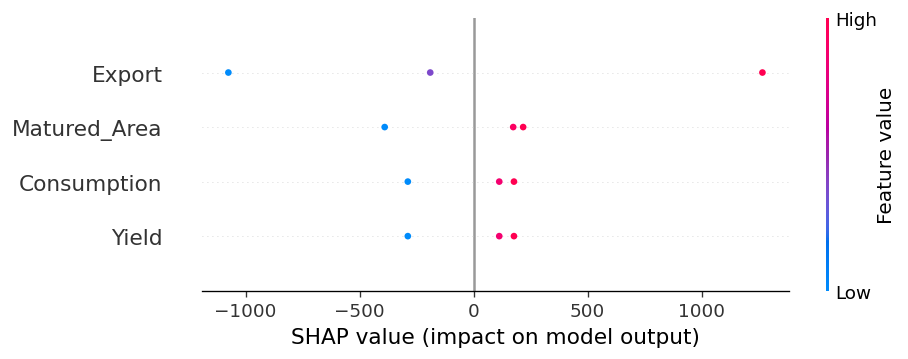

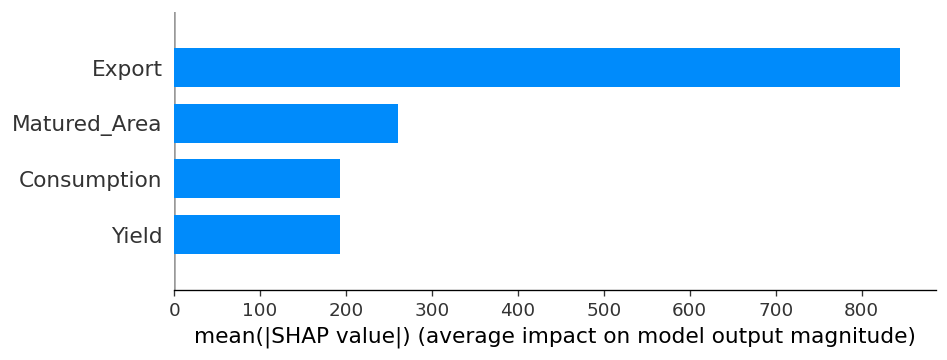

In [68]:
try:
    import shap
    shap.initjs()
    if best_name in ('XGBoost', 'Random Forest'):
        explainer   = shap.TreeExplainer(best_model_obj)
        shap_values = explainer.shap_values(best_X)
    else:
        explainer   = shap.LinearExplainer(best_model_obj, best_X)
        shap_values = explainer.shap_values(best_X)
    print(f"SHAP {best_name}")
    shap.summary_plot(shap_values, best_X, feature_names=FEATURES)
    shap.summary_plot(shap_values, best_X, feature_names=FEATURES, plot_type='bar')
except ImportError:
    print("⚠️  shap tidak terinstal: pip install shap")
except Exception as e:
    print(f"⚠️  SHAP error: {e}")

# Export Model

In [69]:
os.makedirs('models', exist_ok=True)

joblib.dump(lr,     'models/linear_regression.pkl')
joblib.dump(rf,     'models/random_forest.pkl')
joblib.dump(xgb,    'models/xgboost.pkl')
joblib.dump(scaler, 'models/scaler_standard.pkl')
joblib.dump(best_model_obj, 'models/best_model.pkl')

print("Model tersimpan di folder 'models/':")
for f in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{f}')
    print(f" {f:<35} {size/1024:.1f} KB")

Model tersimpan di folder 'models/':
 best_model.pkl                      0.6 KB
 linear_regression.pkl               0.6 KB
 random_forest.pkl                   268.4 KB
 scaler_standard.pkl                 0.7 KB
 xgboost.pkl                         330.0 KB


## 8.1 Validasi Load & Inference Function

In [70]:
mdl_loaded = joblib.load('models/best_model.pkl')
scl_loaded = joblib.load('models/scaler_standard.pkl')
sample_x = X_test[[0]]
if best_name == 'Linear Regression':
    pred = mdl_loaded.predict(scl_loaded.transform(sample_x))[0]
else:
    pred = mdl_loaded.predict(sample_x)[0]
print(f"Round-trip OK")
print(f"   Input   : {dict(zip(FEATURES, X_test[0]))}")
print(f"   Prediksi: {pred:,.2f} ('000 T)")
print(f"   Aktual  : {y_test[0]:,.2f} ('000 T)")
def predict_cpo(matured_area, yield_val, consumption, export, model='best'):
    mdl = joblib.load(f'models/{"best_model" if model=="best" else {"lr":"linear_regression","rf":"random_forest","xgb":"xgboost"}[model]}.pkl')
    scl = joblib.load('models/scaler_standard.pkl')
    X_in = np.array([[matured_area, yield_val, consumption, export]])
    needs_scale = (model == 'lr') or (model == 'best' and best_name == 'Linear Regression')
    if needs_scale:
        X_in = scl.transform(X_in)
    return float(mdl.predict(X_in)[0])
demo = predict_cpo(matured_area=4600, yield_val=3.85,
                   consumption=3200, export=16000)
print(f">>> Demo Prediksi: {demo:,.2f} ('000 Tonnes)")

Round-trip OK
   Input   : {'Matured_Area': np.int64(5217), 'Yield': np.int64(3570), 'Consumption': np.int64(3570), 'Export': np.int64(18471)}
   Prediksi: 20,941.32 ('000 T)
   Aktual  : 19,858.00 ('000 T)
>>> Demo Prediksi: 17,256.73 ('000 Tonnes)


# Summary & Kesimpulan

## Pipeline Checklist

| Tahap | Keterangan |
|---|---|
| ✅ Setup | Library auto-install |
| ✅ Data Download | CPOPC Palm Oil Database send to GitHub @oshlite |
| ✅ Data Understanding | EDA univariate, bivariate, trend, statistik |
| ✅ Data Preparation | Merge, missing value, outlier capping, scaling |
| ✅ Modeling | Linear Regression, Random Forest, XGBoost |
| ✅ Evaluation | MAE, RMSE, R², cross-validation, overlay plot |
| ✅ Feature Analysis | Feature importance RF & XGBoost, Permutation, SHAP |
| ✅ Export | `models/*.pkl` |

## Insight Utama
- **Model terbaik** dipilih otomatis berdasarkan R² tertinggi di test set
- **Faktor dominan** pada umumnya: Matured Area dan Yield adalah driver utama produksi
- Data mencakup **2010–2024** (15 tahun) cukup untuk tren jangka menengah
- Model cocok untuk **estimasi produksi 1–3 tahun** dengan asumsi tren stabil

## Output Files
```
models/
├── best_model.pkl          ← model terbaik (auto-selected)
├── linear_regression.pkl
├── random_forest.pkl
├── xgboost.pkl
└── scaler_standard.pkl
```

*Notebook by oryza surya hapsari/@oshlite/palm-oil-intelligence-platform | ML Pipeline*

Nama : Oryza Surya Hapsari <br>
NPM : 2317051107<br>
https://github.com/oshlite/palm-oil-intelligence-platform